In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy import stats
import pingouin as pg
import numpy as np
import seaborn as sns

In [5]:
ndvi_path = '/Users/tillweiss/Desktop/MODSNOW/data/MODSNOW_irrigated_MarJul_2000_2024/MOD13Q1-061-Statistics.csv'
snow_path = '/Users/tillweiss/Desktop/MODSNOW/data/cloud_snow_fraction_amudarya_kerky_4report.txt'

In [7]:
ndvi = pd.read_csv(ndvi_path)

ndvi['Date'] = pd.to_datetime(ndvi['Date'])
ndvi = ndvi[['Date', 'Mean']]
ndvi = ndvi.rename(columns={'Mean': 'NDVI'})

In [107]:
snow = pd.read_csv(snow_path,
    sep=';',
    header=None,
    engine='python'
)

snow.columns = ['Year', 'Day', 'Snow_Mean', 'Snow_Percent','nn']
snow['Snow_Mean'] = snow['Snow_Mean'].replace(-9, pd.NA)

snow['Date'] = pd.to_datetime(
    snow['Year'].astype(int).astype(str),
    format='%Y'
) + pd.to_timedelta(snow['Day'] - 1, unit='D')

snow = snow[['Date', 'Snow_Percent']]

In [191]:
ndvi_daily = ndvi[['Date', 'NDVI']].set_index('Date').resample('D').asfreq()
snow_daily = snow[['Date', 'Snow_Percent']].set_index('Date').resample('D').asfreq()

snow_ndvi_d = ndvi_daily.join(snow_daily, how='left')
#snow_ndvi_d = snow_ndvi_d[snow_ndvi_d.index.month.isin([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])]


In [192]:
snow_16d = []

ndvi_dates = snow_ndvi_d.index[snow_ndvi_d['NDVI'].notna()]

for d in ndvi_dates:
    window = snow_ndvi_d.loc[d : d + pd.Timedelta(days=15), 'Snow_Percent']
    snow_16d.append(window.mean())

snow_ndvi_d.loc[ndvi_dates, 'Snow_16d'] = snow_16d
snow_ndvi_d = snow_ndvi_d.reset_index()  


In [193]:
snow_ndvi_d

,Date,NDVI,Snow_Percent,Snow_16d
0,2000-02-18,0.100339,NaN,56.7125
1,2000-02-19,NaN,NaN,NaN
2,2000-02-20,NaN,NaN,NaN
3,2000-02-21,NaN,NaN,NaN
4,2000-02-22,NaN,NaN,NaN
...,...,...,...,...
9320,2025-08-25,NaN,NaN,NaN
9321,2025-08-26,NaN,NaN,NaN
9322,2025-08-27,NaN,NaN,NaN
9323,2025-08-28,NaN,NaN,NaN


In [194]:
df = snow_ndvi_d.copy()

df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df['DOY'] = df['Date'].dt.dayofyear

df = df.dropna()



In [195]:
ndvi_snow = df.copy()
snow_data = pd.DataFrame(ndvi_snow, columns=['Date', 'Snow_Percent', 'Snow_16d', 'Year', 'Month', 'DOY'])
snow_data.to_csv('/Users/tillweiss/Desktop/MODSNOW/data/snow_agg.csv', index=False, header=True)

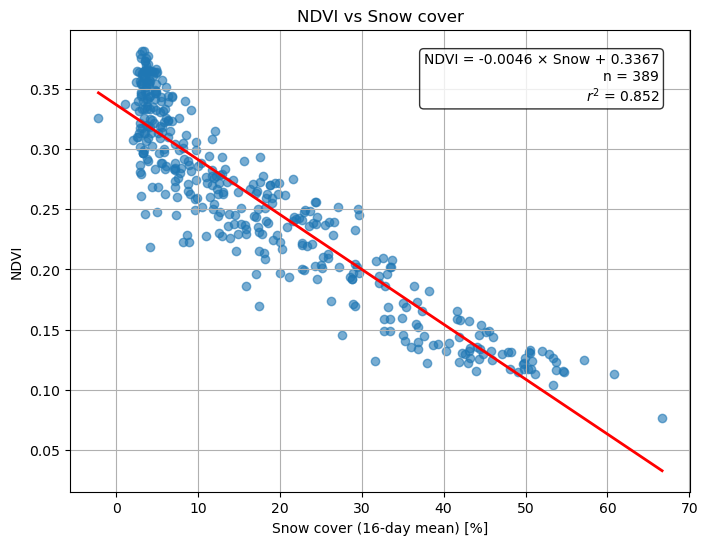

Pearson correlation: -0.923, p-value = 1.326e-162
Spearman correlation: -0.913, p-value = 3.505e-153
Regression slope: -0.0046
Regression intercept: 0.3367
Regression p-value: 1.326e-162


In [ ]:
df_corr = ndvi_snow[['NDVI', 'Snow_16d']].dropna()

x = df_corr['Snow_16d']
y = df_corr['NDVI']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = intercept + slope * x_fit

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.6, label='Data')
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Linear regression')

plt.xlabel('Snow cover (16-day mean) [%]')
plt.ylabel('NDVI')
plt.title('NDVI vs Snow cover')
plt.grid(True)

n_obs = len(df_corr)

plt.text(
    0.95, 0.95,
    f'NDVI = {slope:.4f} × Snow + {intercept:.4f}\n'
    f'n = {n_obs}\n'
    f'$r^2$ = {r_value**2:.3f}',
    transform=plt.gca().transAxes,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.show()

pearson_coef, pearson_p = stats.pearsonr(x, y)
spearman_coef, spearman_p = stats.spearmanr(x, y)

print(f'Pearson correlation: {pearson_coef:.3f}, p-value = {pearson_p:.3e}')
print(f'Spearman correlation: {spearman_coef:.3f}, p-value = {spearman_p:.3e}')

print(f'Regression slope: {slope:.4f}')
print(f'Regression intercept: {intercept:.4f}')
print(f'Regression p-value: {p_value:.3e}')

- Looking at 16 day NDVI and correspoding snow coverage shows strong negative correlation
- High snow coaverage -> low NDVI
- But looking at snow mean over 16 days here corresponding to NDVI
- Including all snow values, includes seasonal trend

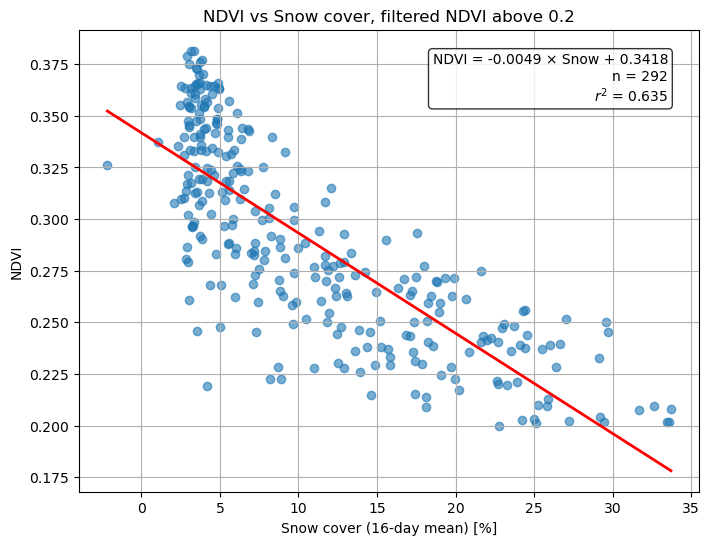

Pearson correlation: -0.797, p-value = 2.257e-65
Spearman correlation: -0.814, p-value = 2.557e-70
Regression slope: -0.0049
Regression intercept: 0.3418
Regression p-value: 2.257e-65


In [180]:
df_corr = ndvi_snow[['NDVI', 'Snow_16d']].dropna()

df_corr = df_corr[df_corr['NDVI'] >= 0.2]

x = df_corr['Snow_16d']
y = df_corr['NDVI']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = intercept + slope * x_fit

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.6, label='Data')
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Linear regression')

plt.xlabel('Snow cover (16-day mean) [%]')
plt.ylabel('NDVI')
plt.title('NDVI vs Snow cover, filtered NDVI above 0.2')
plt.grid(True)

n_obs = len(df_corr)

plt.text(
    0.95, 0.95,
    f'NDVI = {slope:.4f} × Snow + {intercept:.4f}\n'
    f'n = {n_obs}\n'
    f'$r^2$ = {r_value**2:.3f}',
    transform=plt.gca().transAxes,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.show()

pearson_coef, pearson_p = stats.pearsonr(x, y)
spearman_coef, spearman_p = stats.spearmanr(x, y)

print(f'Pearson correlation: {pearson_coef:.3f}, p-value = {pearson_p:.3e}')
print(f'Spearman correlation: {spearman_coef:.3f}, p-value = {spearman_p:.3e}')

print(f'Regression slope: {slope:.4f}')
print(f'Regression intercept: {intercept:.4f}')
print(f'Regression p-value: {p_value:.3e}')


In [157]:
march_snow = (
    ndvi_snow[ndvi_snow['Month'] == 3]
    .groupby(['Year', 'Month'])['Snow_Percent']
    .mean()
    .reset_index()
    .rename(columns={'Snow_Percent': 'March_Snow'})
    .drop(columns='Month')
)

months = [3, 4, 5, 6, 7, 8]
month_names = ['March', 'April', 'May', 'June', 'July', 'August']

- Averageing snow values for march of each year

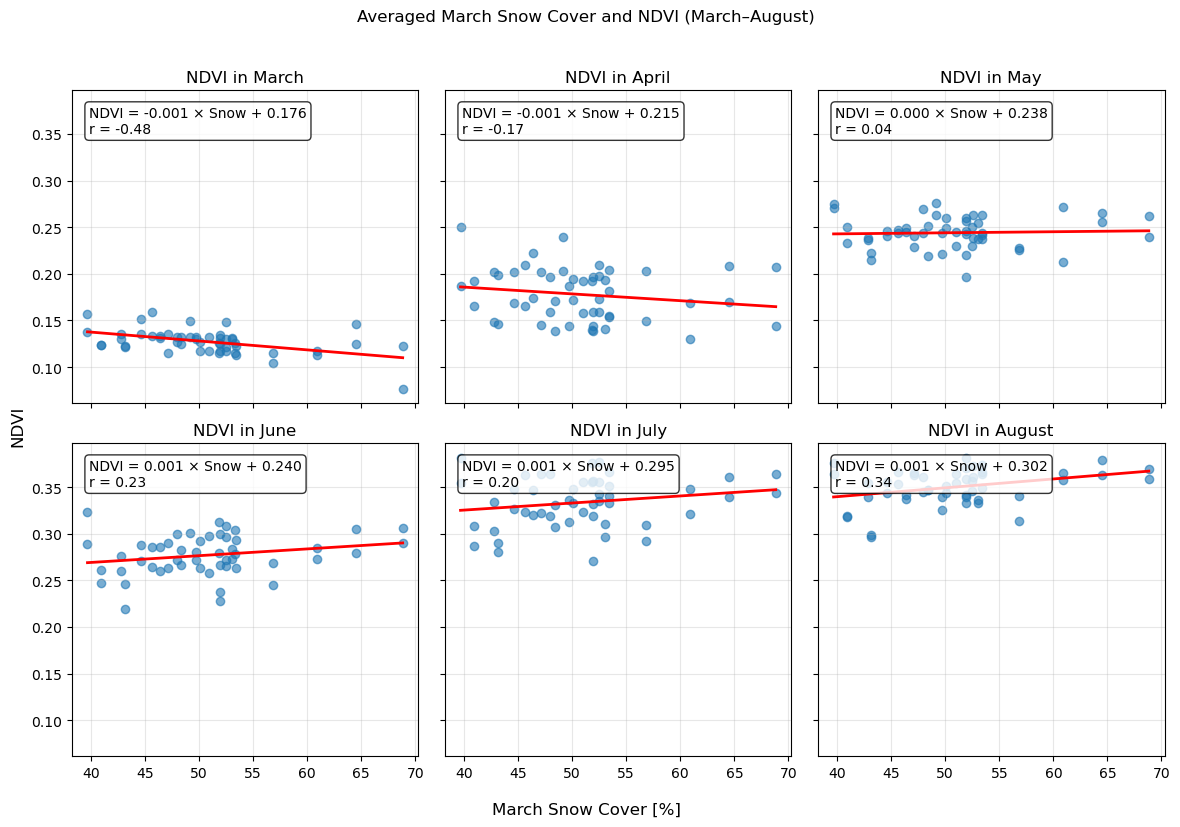

In [88]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, m, name in zip(axes, months, month_names):

    ndvi_m = ndvi_snow[ndvi_snow['Month'] == m]

    aligned = march_snow.merge(ndvi_m, on='Year', how='inner')

    x = aligned['March_Snow']
    y = aligned['NDVI']

    # Scatter
    ax.scatter(x, y, alpha=0.6)

    # Only fit regression if enough points
    if len(aligned) >= 3:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = intercept + slope * x_fit

        ax.plot(x_fit, y_fit, linewidth=2, color='r')

        ax.text(
            0.05, 0.95,
            f'NDVI = {slope:.3f} × Snow + {intercept:.3f}\n'
            f'r = {r_value:.2f}',
            transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )
    else:
        ax.text(
            0.05, 0.95,
            'n < 3',
            transform=ax.transAxes,
            va='top', ha='left'
        )

    ax.set_title(f'NDVI in {name}')
    ax.grid(True, alpha=0.3)

fig.supxlabel('March Snow Cover [%]')
fig.supylabel('NDVI')
fig.suptitle('Averaged March Snow Cover and NDVI (March–August)', y=1.02)

plt.tight_layout()
plt.show()


Compares the averged march snow cover over 30 days to NDVI (2x per month)

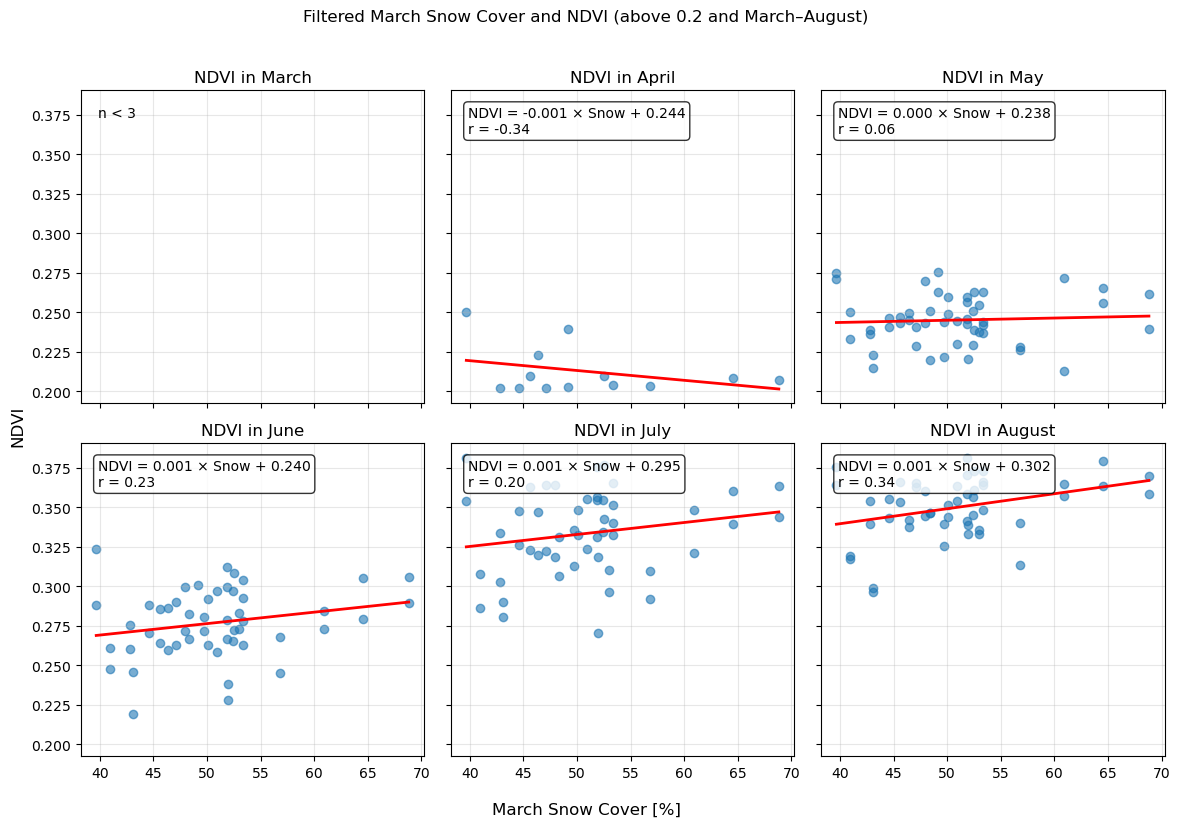

In [89]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, m, name in zip(axes, months, month_names):

    ndvi_m = (
        ndvi_snow[ndvi_snow['Month'] == m]
    )
    ndvi_m = ndvi_m[ndvi_m['NDVI'] >= 0.2]

    aligned = march_snow.merge(ndvi_m, on='Year', how='inner')

    x = aligned['March_Snow']
    y = aligned['NDVI']

    # Scatter plot
    ax.scatter(x, y, alpha=0.6)

    # Regression (only if enough data)
    if len(aligned) >= 3:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = intercept + slope * x_fit

        ax.plot(x_fit, y_fit, linewidth=2, color='r')

        ax.text(
            0.05, 0.95,
            f'NDVI = {slope:.3f} × Snow + {intercept:.3f}\n'
            f'r = {r_value:.2f}',
            transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )
    else:
        ax.text(
            0.05, 0.95,
            'n < 3',
            transform=ax.transAxes,
            va='top', ha='left'
        )

    ax.set_title(f'NDVI in {name}')
    ax.grid(True, alpha=0.3)

fig.supxlabel('March Snow Cover [%]')
fig.supylabel('NDVI')
fig.suptitle('Filtered March Snow Cover and NDVI (above 0.2 and March–August)', y=1.02)

plt.tight_layout()
plt.show()


Introduces as thershold .2 to filter out low ndvi pixel

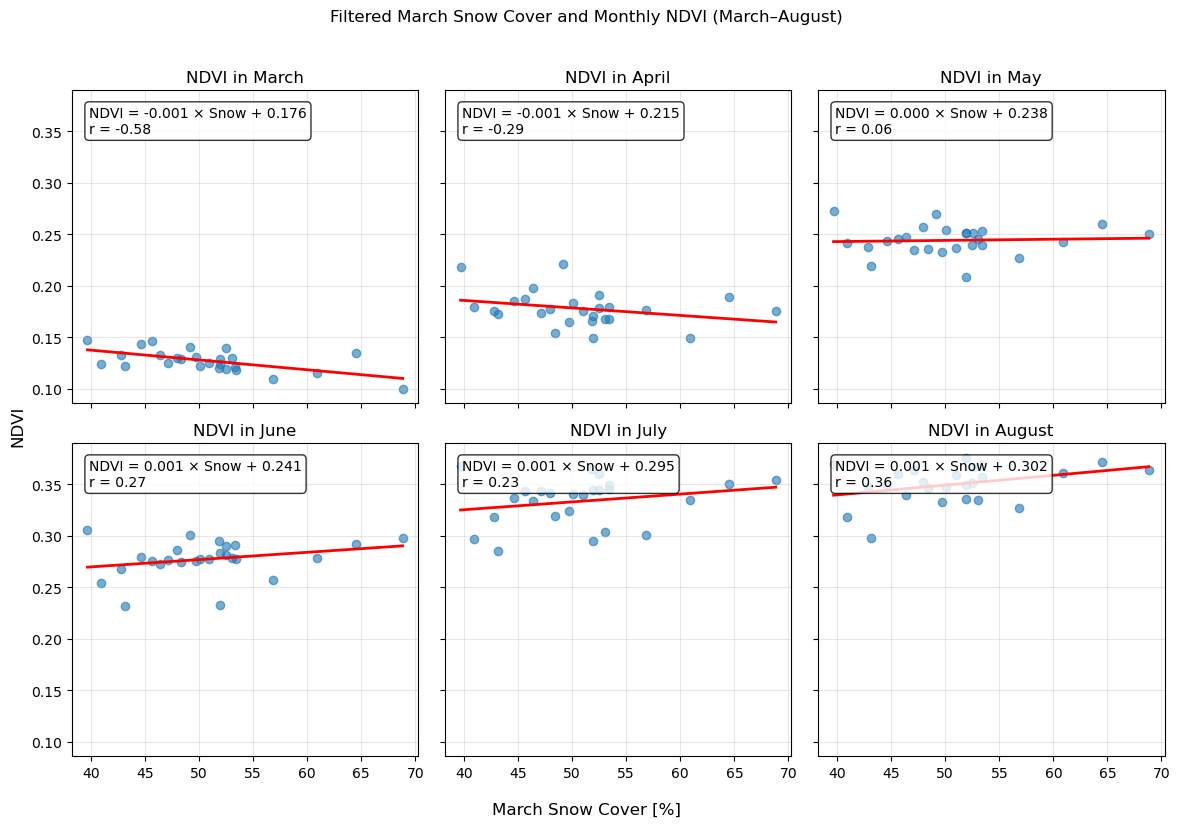

In [20]:
ndvi_monthly = (
    ndvi_snow
    .groupby(['Year', 'Month'], as_index=False)
    .agg(NDVI=('NDVI', 'mean'))  
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, m, name in zip(axes, months, month_names):

    ndvi_m = ndvi_monthly[ndvi_monthly['Month'] == m].copy()
    #ndvi_m = ndvi_m[ndvi_m['NDVI'] >= 0.2]

    aligned = march_snow.merge(ndvi_m, on='Year', how='inner')

    x = aligned['March_Snow']
    y = aligned['NDVI']

    ax.scatter(x, y, alpha=0.6)

    if len(aligned) >= 3:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = intercept + slope * x_fit

        ax.plot(x_fit, y_fit, linewidth=2, color='r')

        ax.text(
            0.05, 0.95,
            f'NDVI = {slope:.3f} × Snow + {intercept:.3f}\n'
            f'r = {r_value:.2f}',
            transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )
    else:
        ax.text(
            0.05, 0.95,
            'n < 3',
            transform=ax.transAxes,
            va='top', ha='left'
        )

    ax.set_title(f'NDVI in {name}')
    ax.grid(True, alpha=0.3)

fig.supxlabel('March Snow Cover [%]')
fig.supylabel('NDVI')
fig.suptitle('Filtered March Snow Cover and Monthly NDVI (March–August)', y=1.02)

plt.tight_layout()
plt.show()


Compares mean march sca to monthly ndvi 

In [ ]:
ndvi_snow

In [127]:
ndvi_wide = ndvi_snow.pivot(index='Year', columns='DOY', values='NDVI')
snow_wide = ndvi_snow.pivot(index='Year', columns='DOY', values='Snow_16d')

In [158]:
corr_matrix = pd.DataFrame(
    index=ndvi_wide.columns,
    columns=snow_wide.columns,
    dtype=float
)

for ndvi_doy in ndvi_wide.columns:
    for snow_doy in snow_wide.columns:
        x = ndvi_wide[ndvi_doy]
        y = snow_wide[snow_doy]

        valid = x.notna() & y.notna()

        if valid.sum() >= 5:  
            corr_matrix.loc[ndvi_doy, snow_doy] = x[valid].corr(y[valid])
        else:
            corr_matrix.loc[ndvi_doy, snow_doy] = np.nan


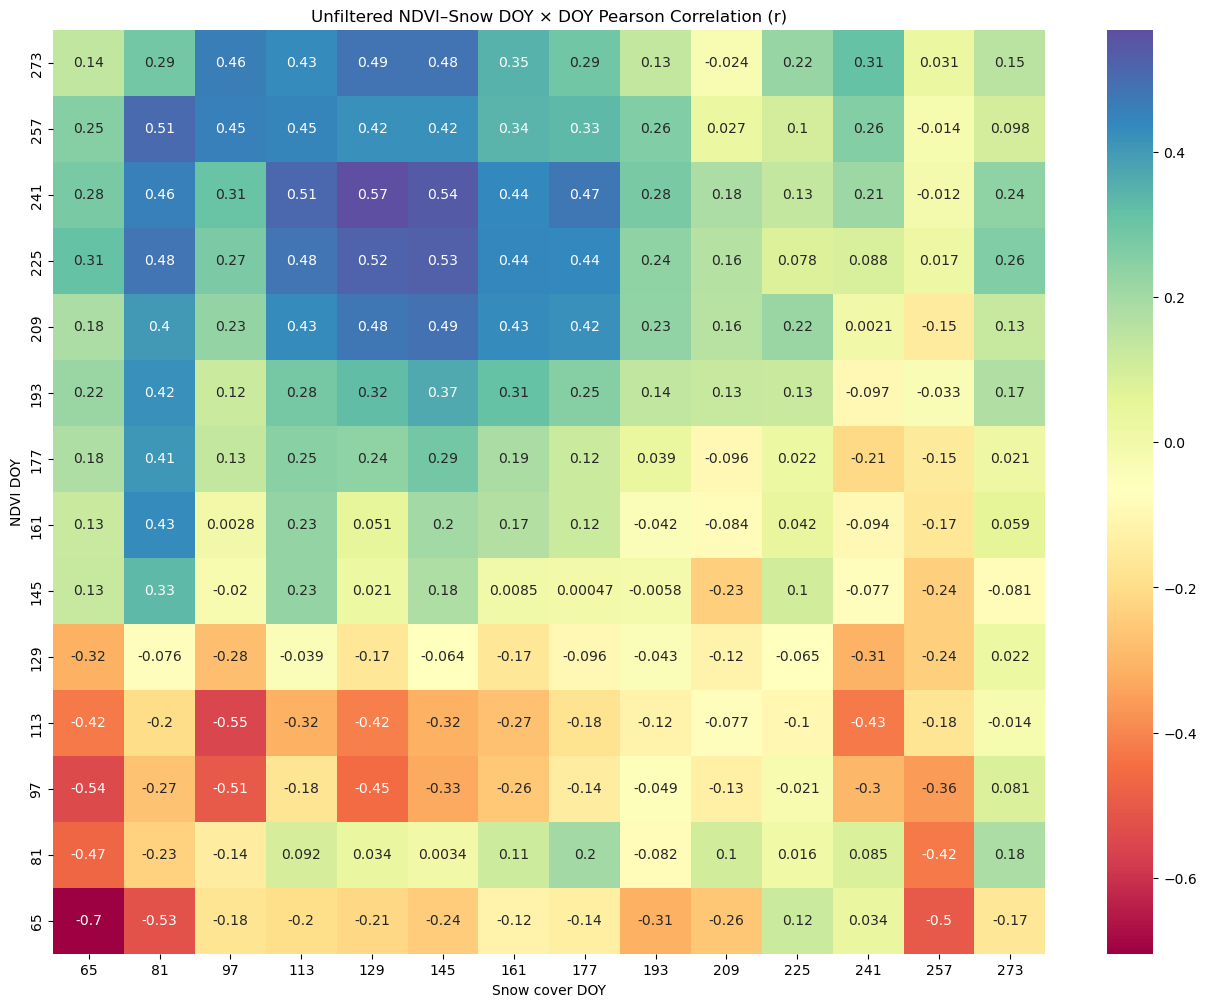

In [159]:
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, annot=True, cmap='Spectral').invert_yaxis()

plt.xlabel('Snow cover DOY')
plt.ylabel('NDVI DOY')
plt.title('Unfiltered NDVI–Snow DOY × DOY Pearson Correlation (r)')
plt.show()

In [160]:
doys = ndvi_wide.columns

r_mat = pd.DataFrame(index=doys, columns=doys, dtype=float)
p_mat = pd.DataFrame(index=doys, columns=doys, dtype=float)
ci_low_mat = pd.DataFrame(index=doys, columns=doys, dtype=float)
ci_high_mat = pd.DataFrame(index=doys, columns=doys, dtype=float)

for ndvi_doy in doys:
    for snow_doy in doys:
        res = pg.corr(
            ndvi_wide[ndvi_doy],
            snow_wide[snow_doy],
            method="pearson"
        )

        r_mat.loc[ndvi_doy, snow_doy] = res["r"].iloc[0]
        p_mat.loc[ndvi_doy, snow_doy] = res["p-val"].iloc[0]
        ci_low_mat.loc[ndvi_doy, snow_doy] = res["CI95%"].iloc[0][0]
        ci_high_mat.loc[ndvi_doy, snow_doy] = res["CI95%"].iloc[0][1]


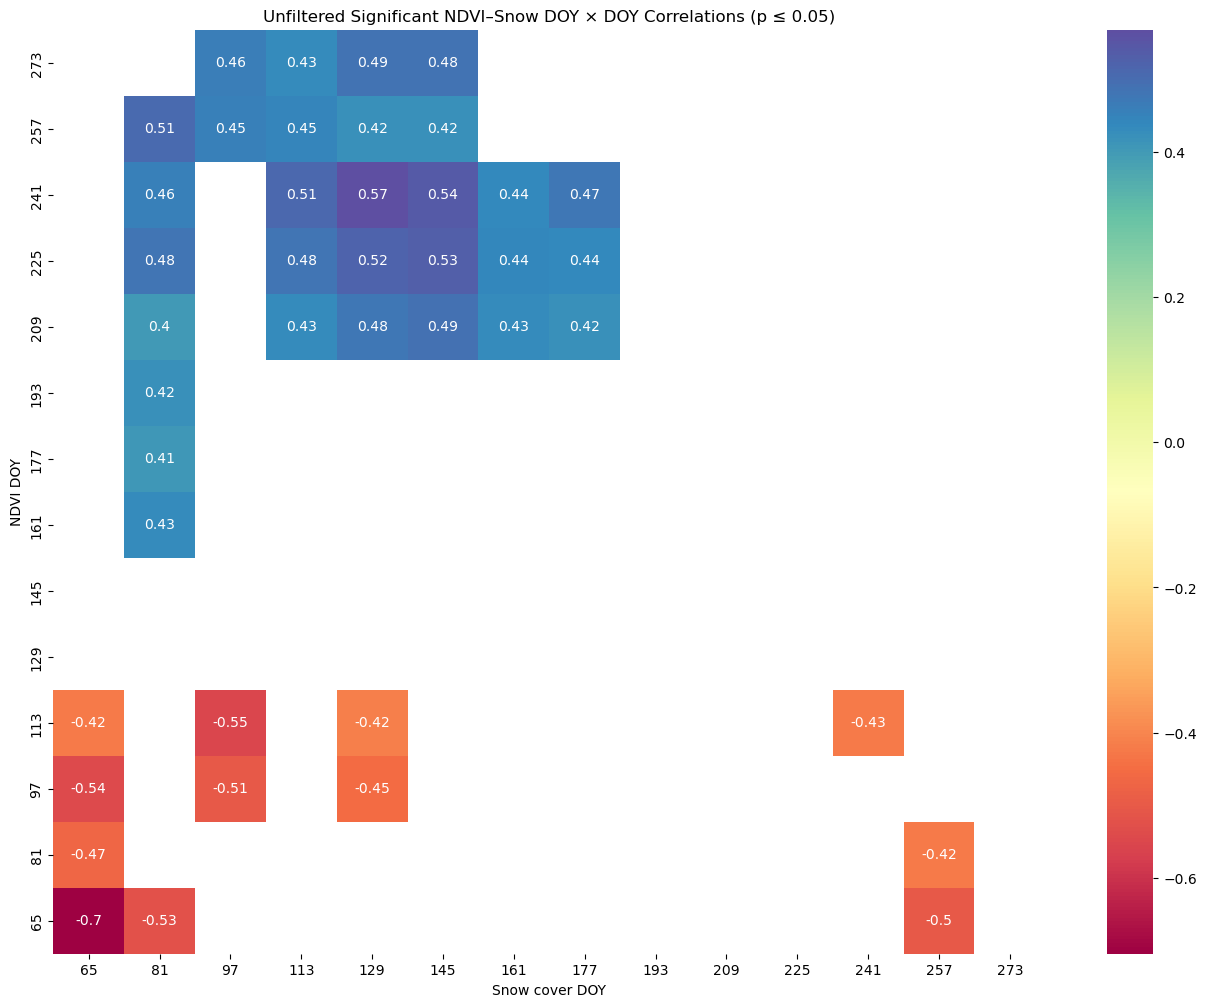

In [133]:
r_sig = r_mat.copy()
r_sig[p_mat > 0.05] = np.nan

plt.figure(figsize=(16,12))
sns.heatmap(r_sig, annot=True, cmap='Spectral').invert_yaxis()

plt.xlabel('Snow cover DOY')
plt.ylabel('NDVI DOY')
plt.title('Unfiltered Significant NDVI–Snow DOY × DOY Correlations (p ≤ 0.05)')
plt.show()

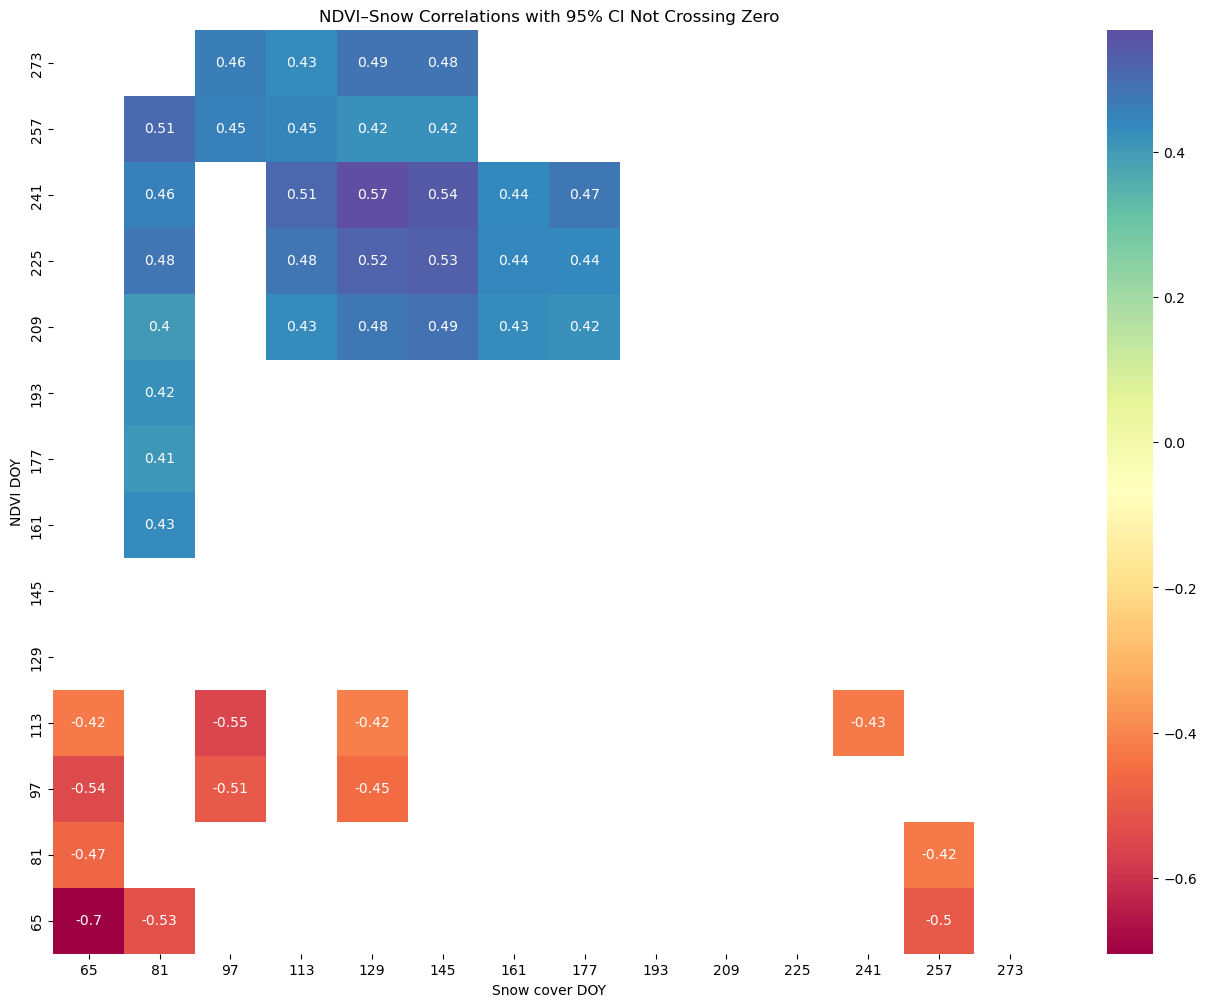

In [33]:
ci_significant = ~(
    (ci_low_mat <= 0) & (ci_high_mat >= 0)
)

r_ci_sig = r_mat.copy()
r_ci_sig[~ci_significant] = np.nan

plt.figure(figsize=(16,12))
sns.heatmap(r_ci_sig, annot=True, cmap='Spectral').invert_yaxis()

plt.xlabel('Snow cover DOY')
plt.ylabel('NDVI DOY')
plt.title('NDVI–Snow Correlations with 95% CI Not Crossing Zero')
plt.show()

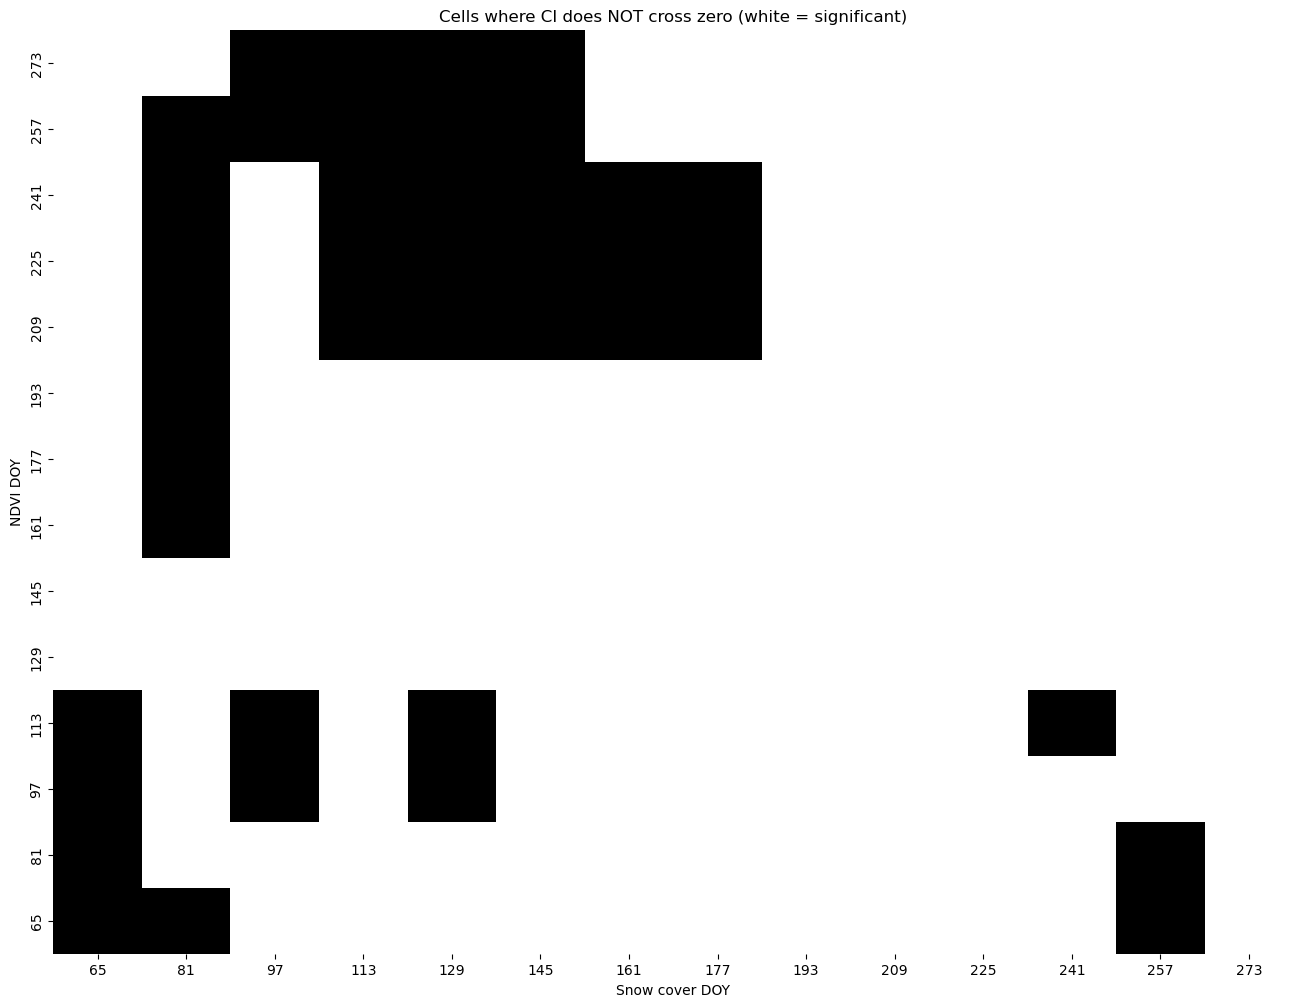

In [ ]:
fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(ci_significant.astype(int), cmap="Greys",ax=ax,cbar=False).invert_yaxis()

plt.xlabel('Snow cover DOY')
plt.ylabel('NDVI DOY')
ax.set_title("Cells where CI does NOT cross zero (white = significant)")
plt.show()


In [ ]:
i, j = 209, 129 
print("r:", r_mat.loc[i, j])
print("p:", p_mat.loc[i, j])
print("CI:", ci_low_mat.loc[i, j], ci_high_mat.loc[i, j])


r: 0.47790374006389796
p: 0.015683619324712295
CI: 0.1 0.73


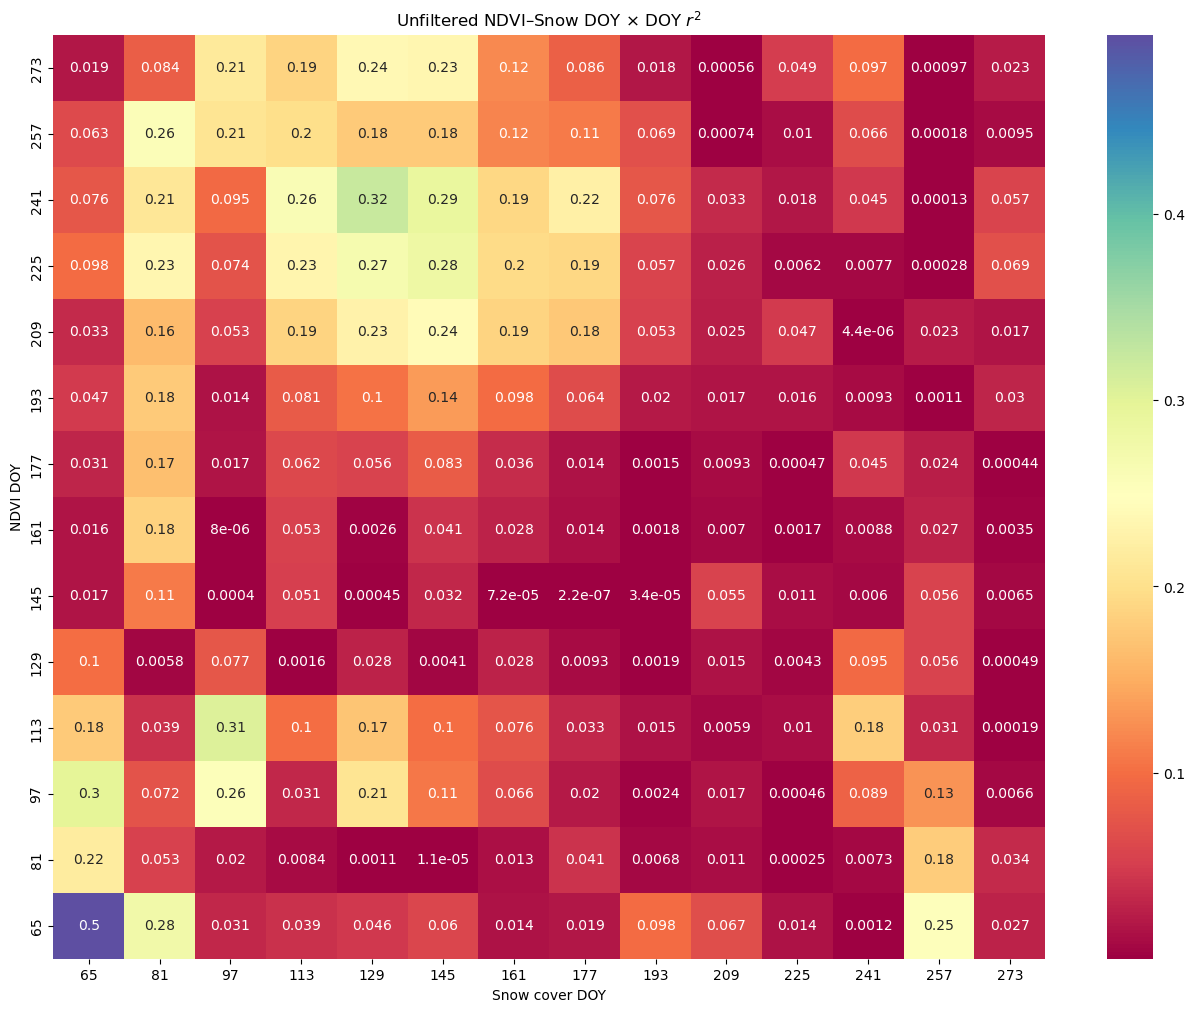

In [161]:
corr2_matrix = pd.DataFrame(
    index=ndvi_wide.columns,
    columns=snow_wide.columns,
    dtype=float
)

for ndvi_doy in ndvi_wide.columns:
    for snow_doy in snow_wide.columns:
        x = ndvi_wide[ndvi_doy]
        y = snow_wide[snow_doy]

        valid = x.notna() & y.notna()

        if valid.sum() >= 5:  
            r = x[valid].corr(y[valid])
            corr2_matrix.loc[ndvi_doy, snow_doy] = r ** 2
            
        else:
            corr2_matrix.loc[ndvi_doy, snow_doy] = np.nan

plt.figure(figsize=(16,12))
sns.heatmap(corr2_matrix, annot=True, cmap='Spectral').invert_yaxis()

plt.xlabel('Snow cover DOY')
plt.ylabel('NDVI DOY')
plt.title('Unfiltered NDVI–Snow DOY × DOY $r^2$')
plt.show()

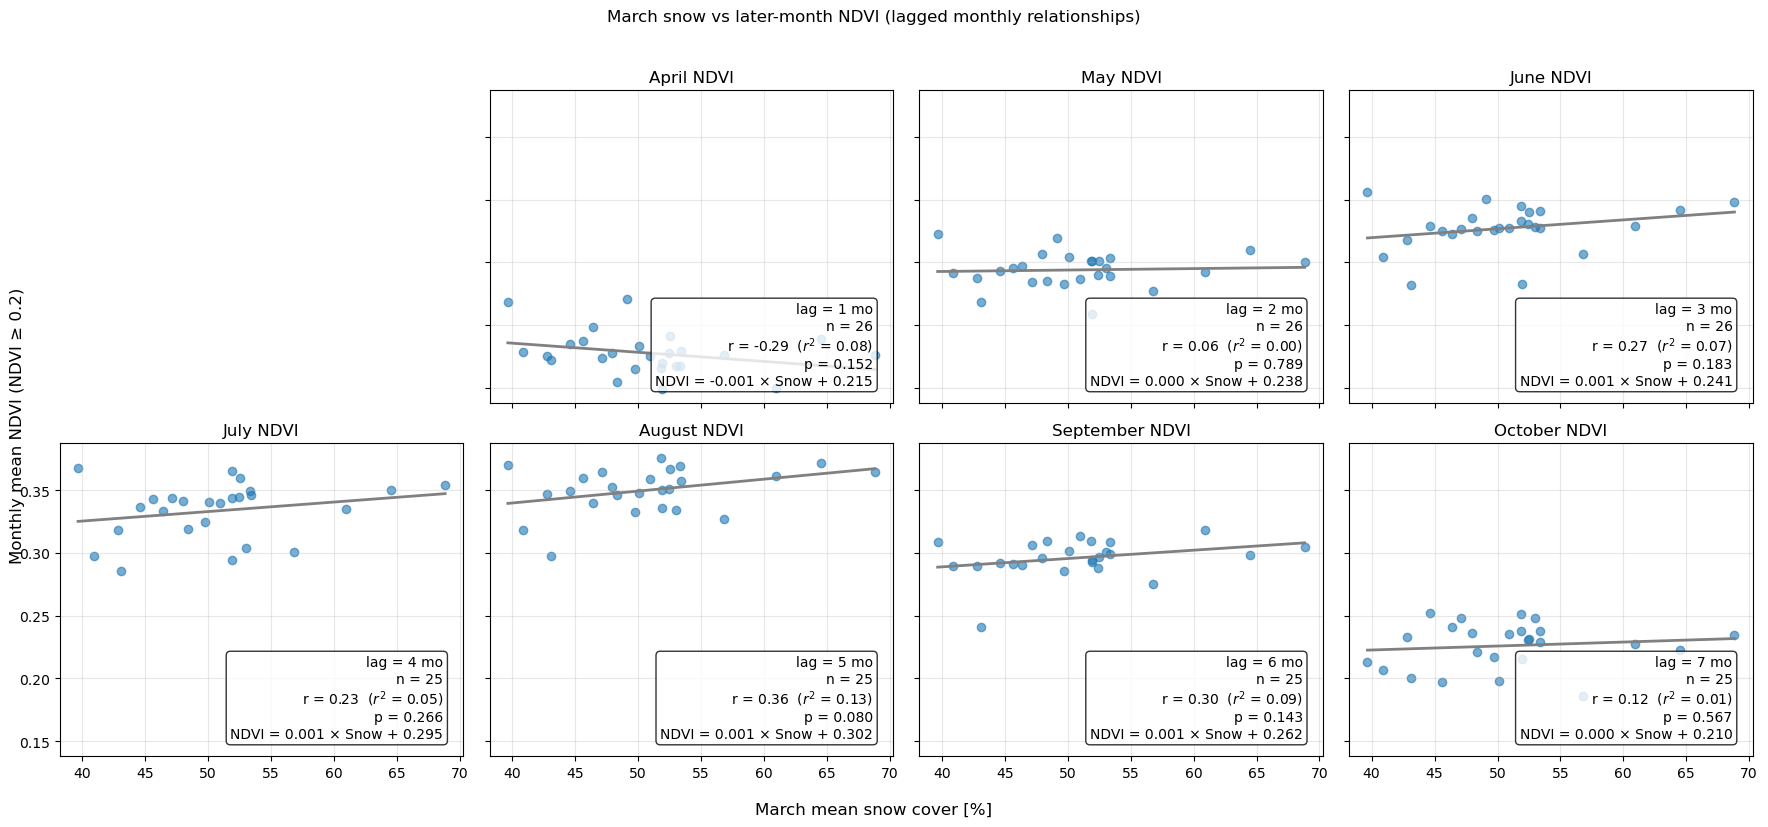

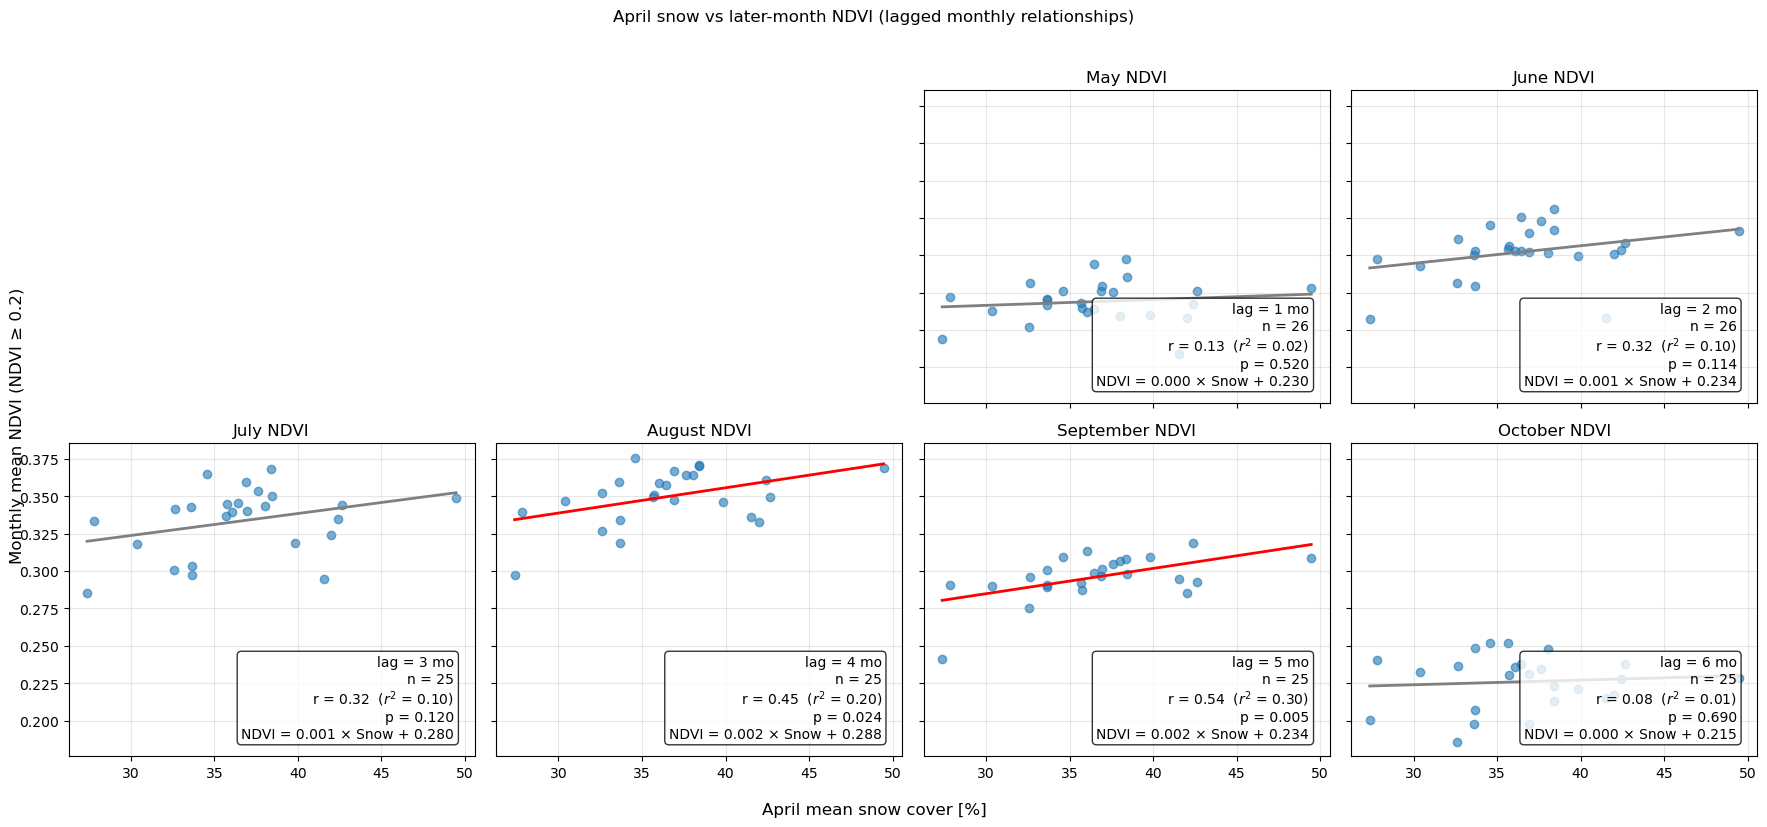

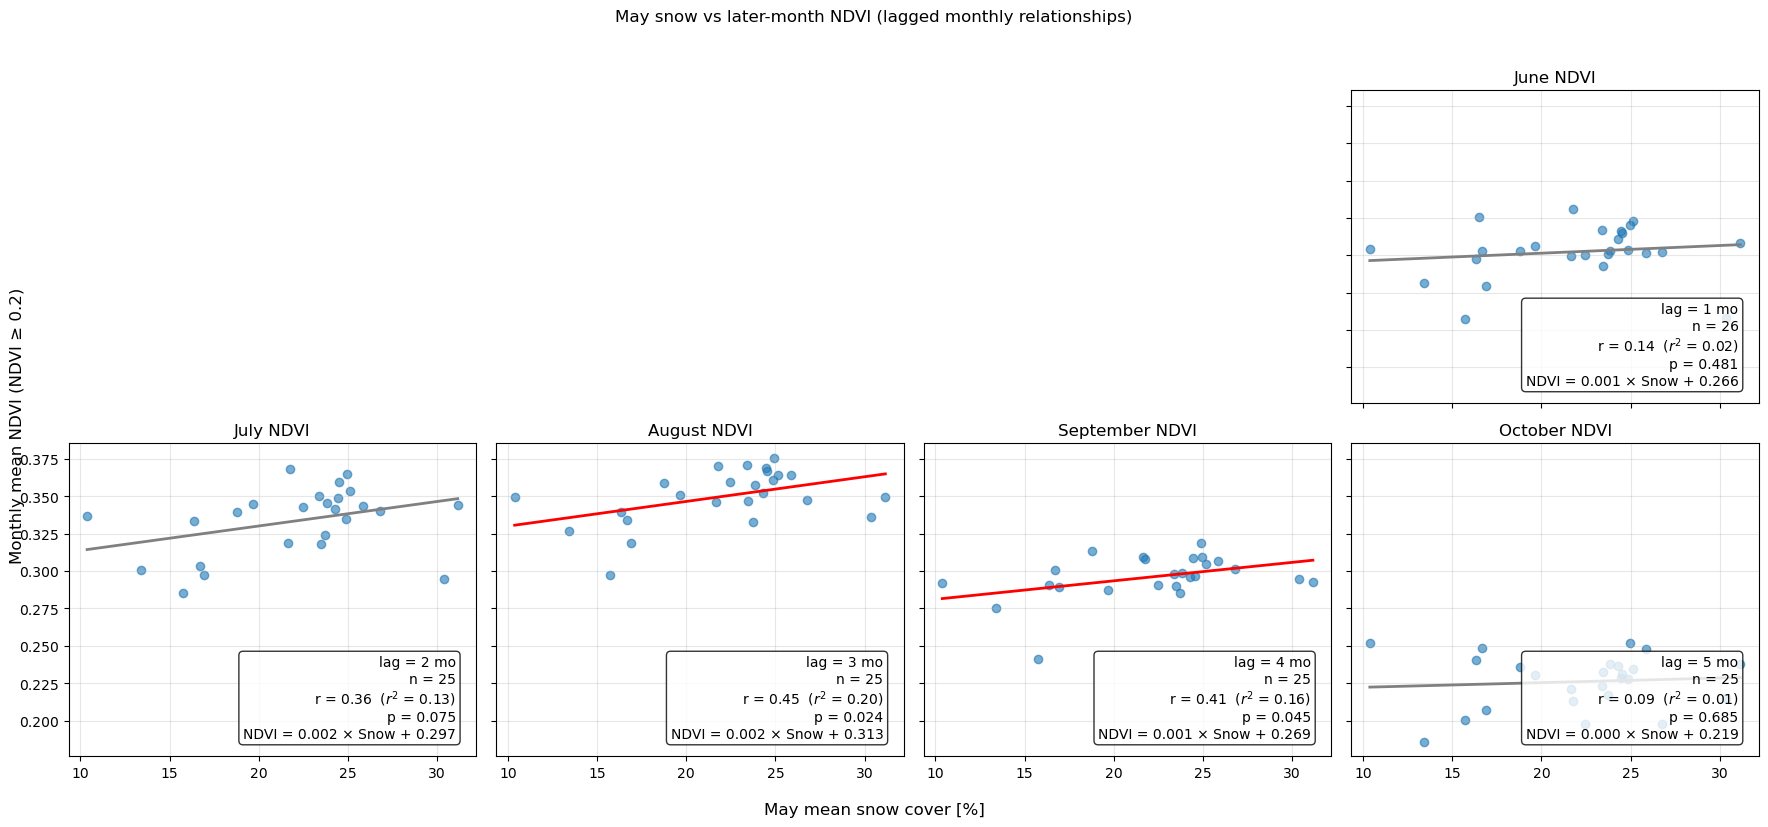

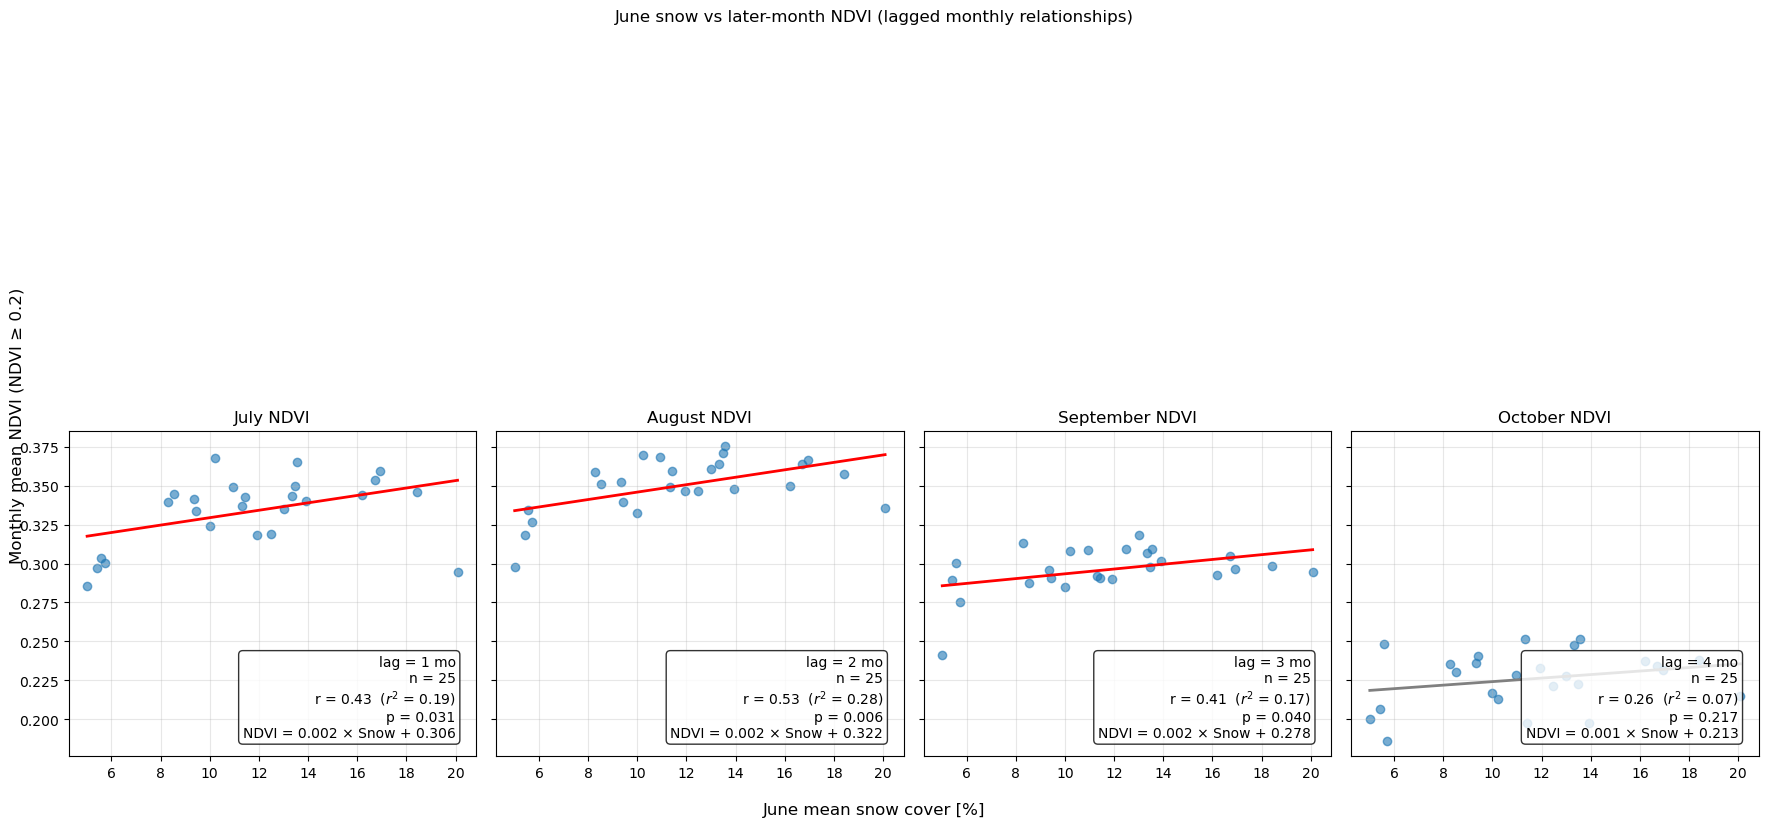

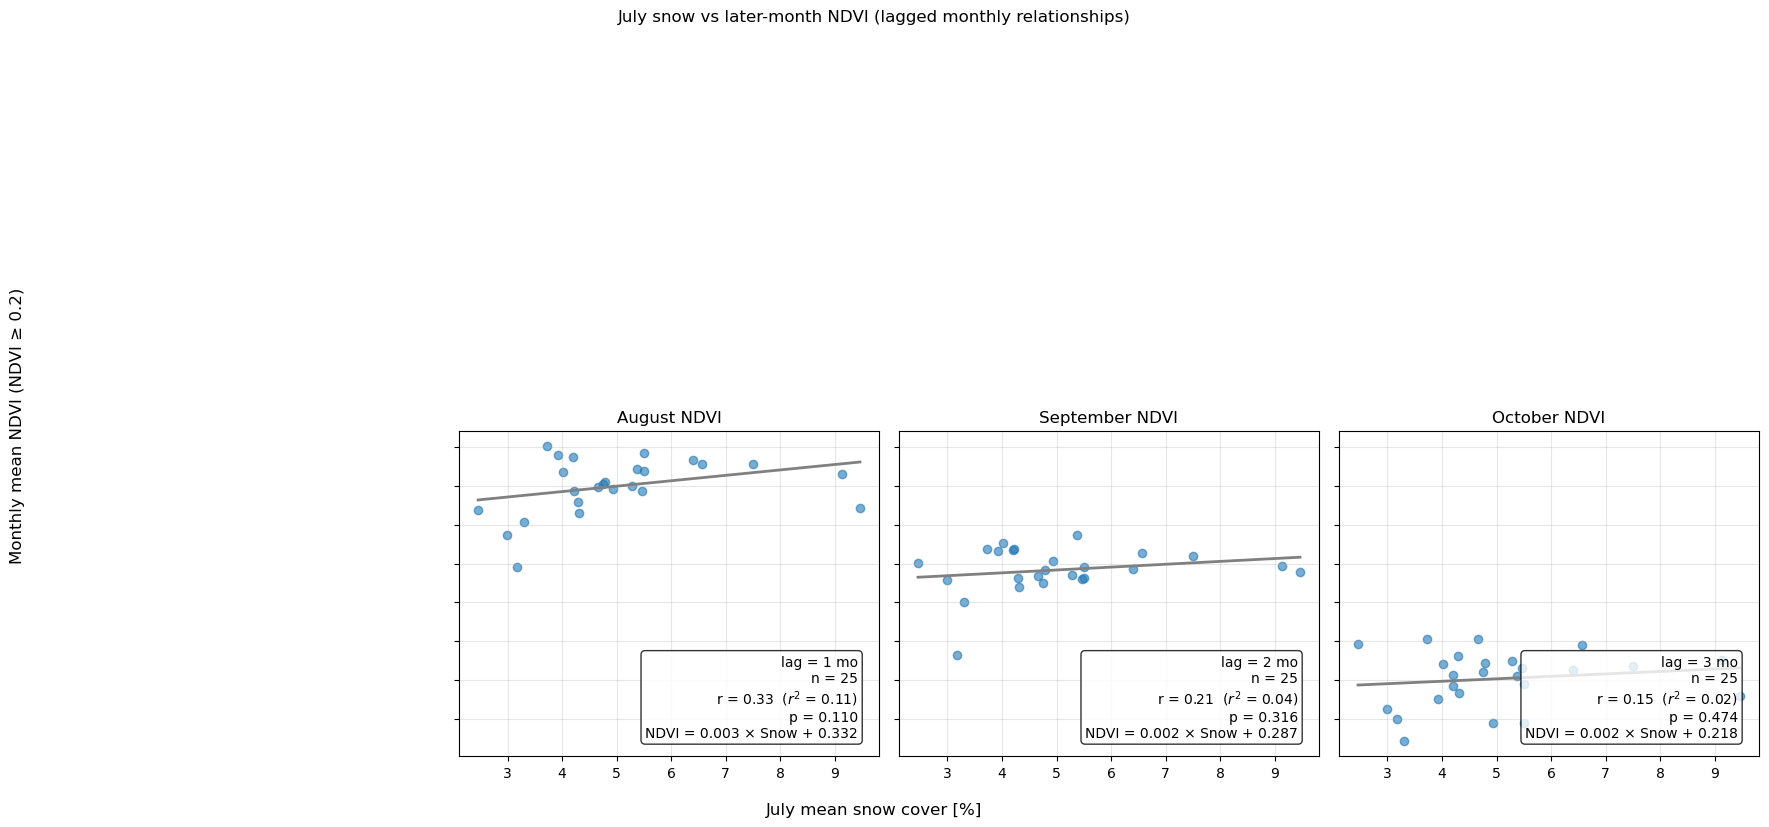

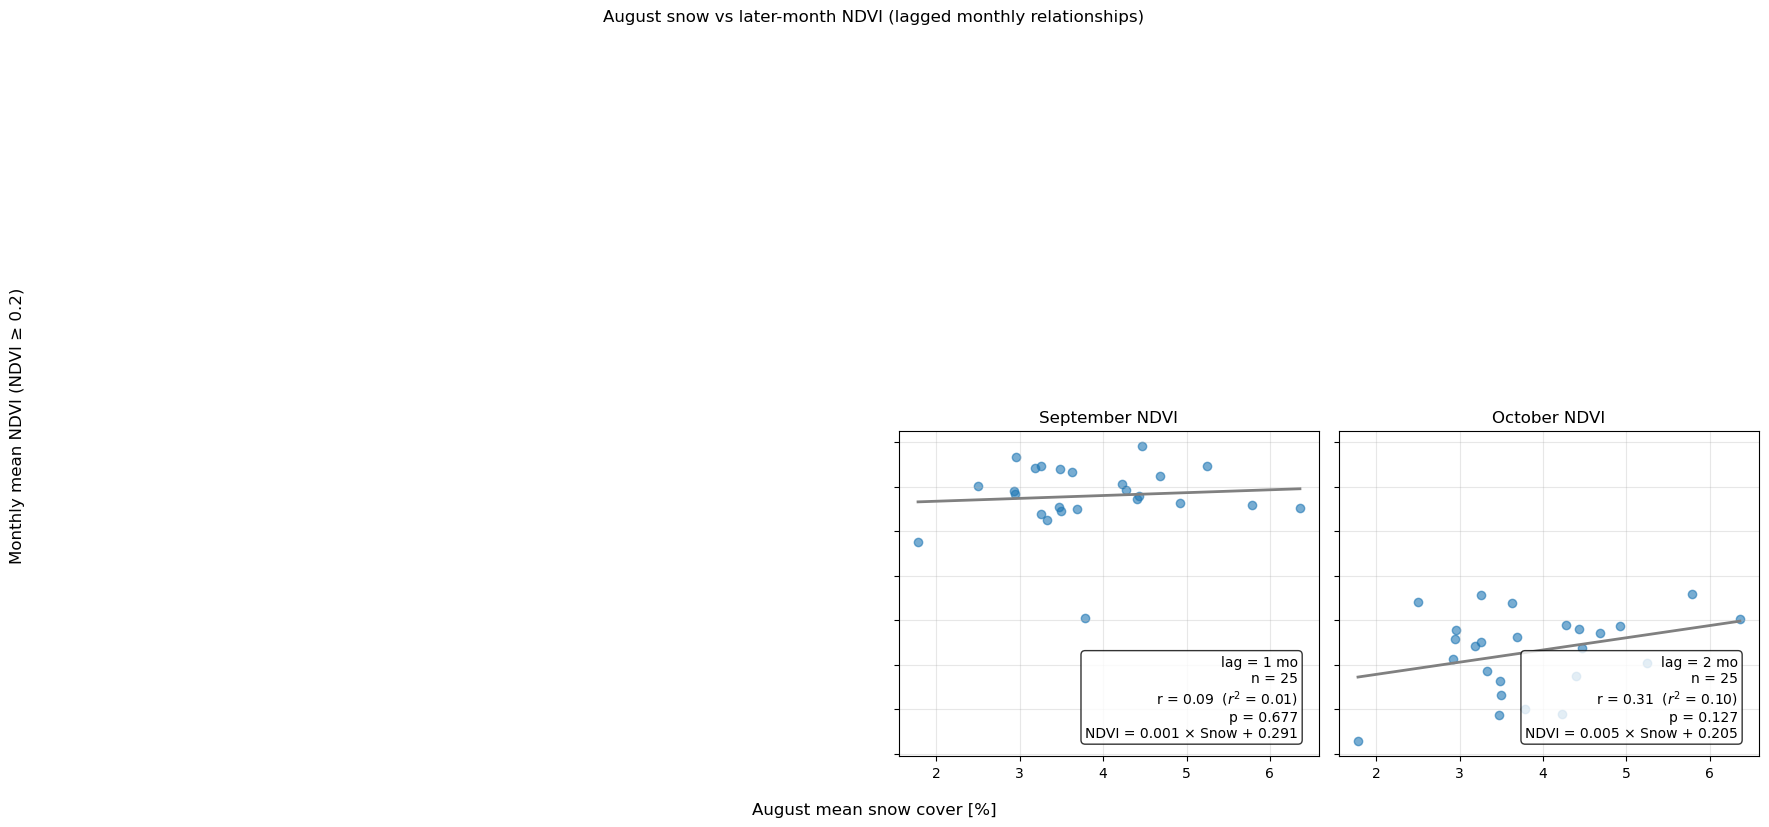

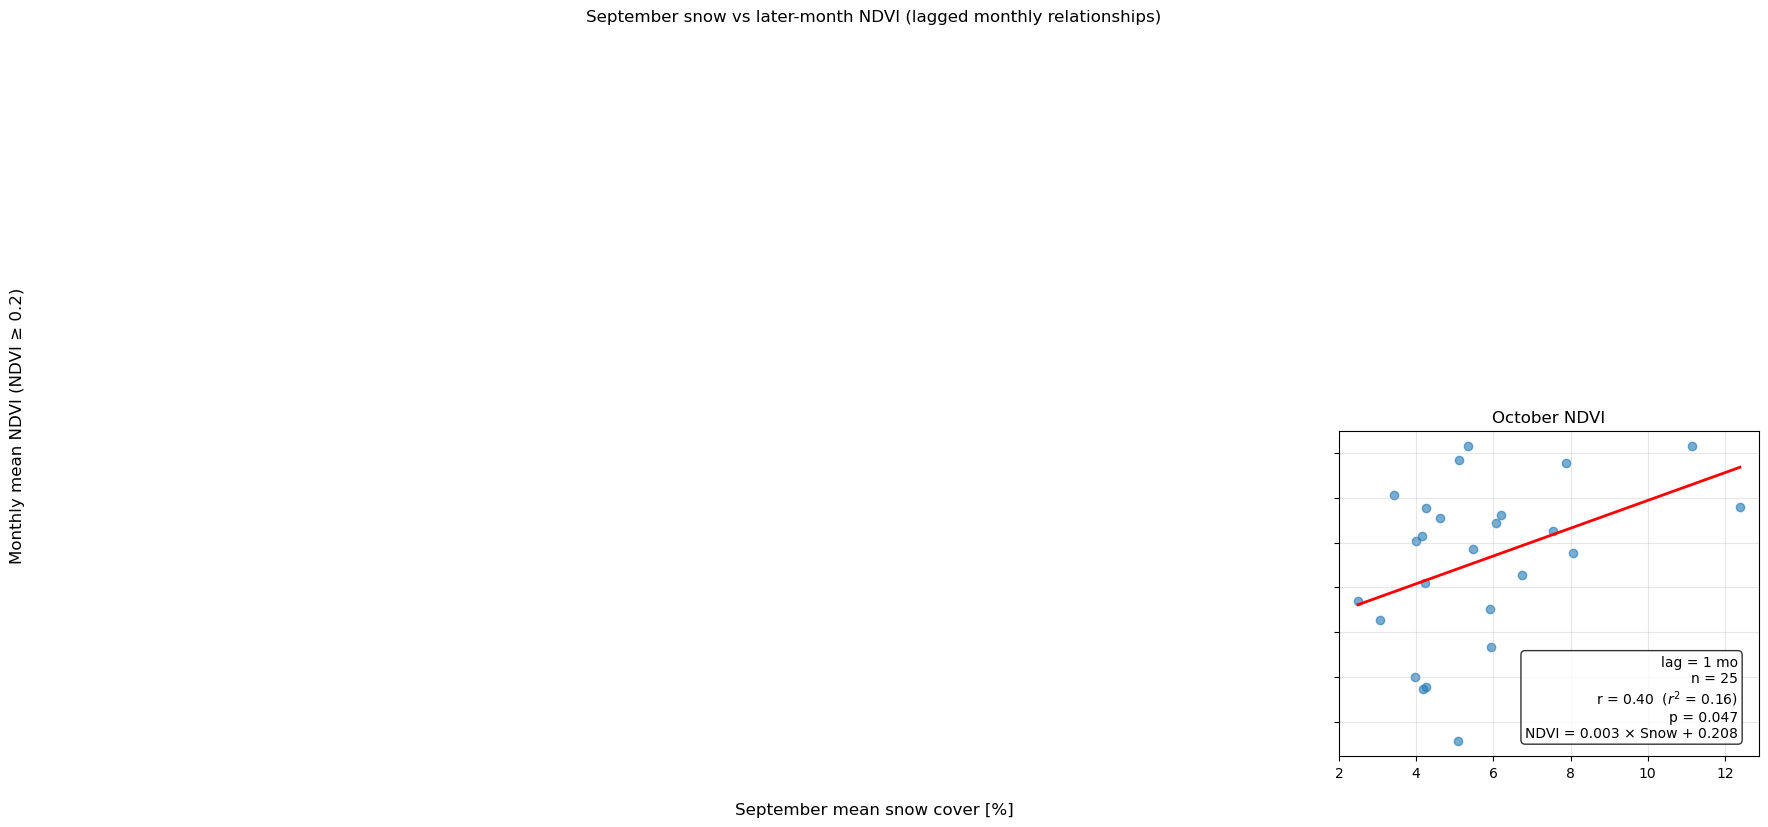

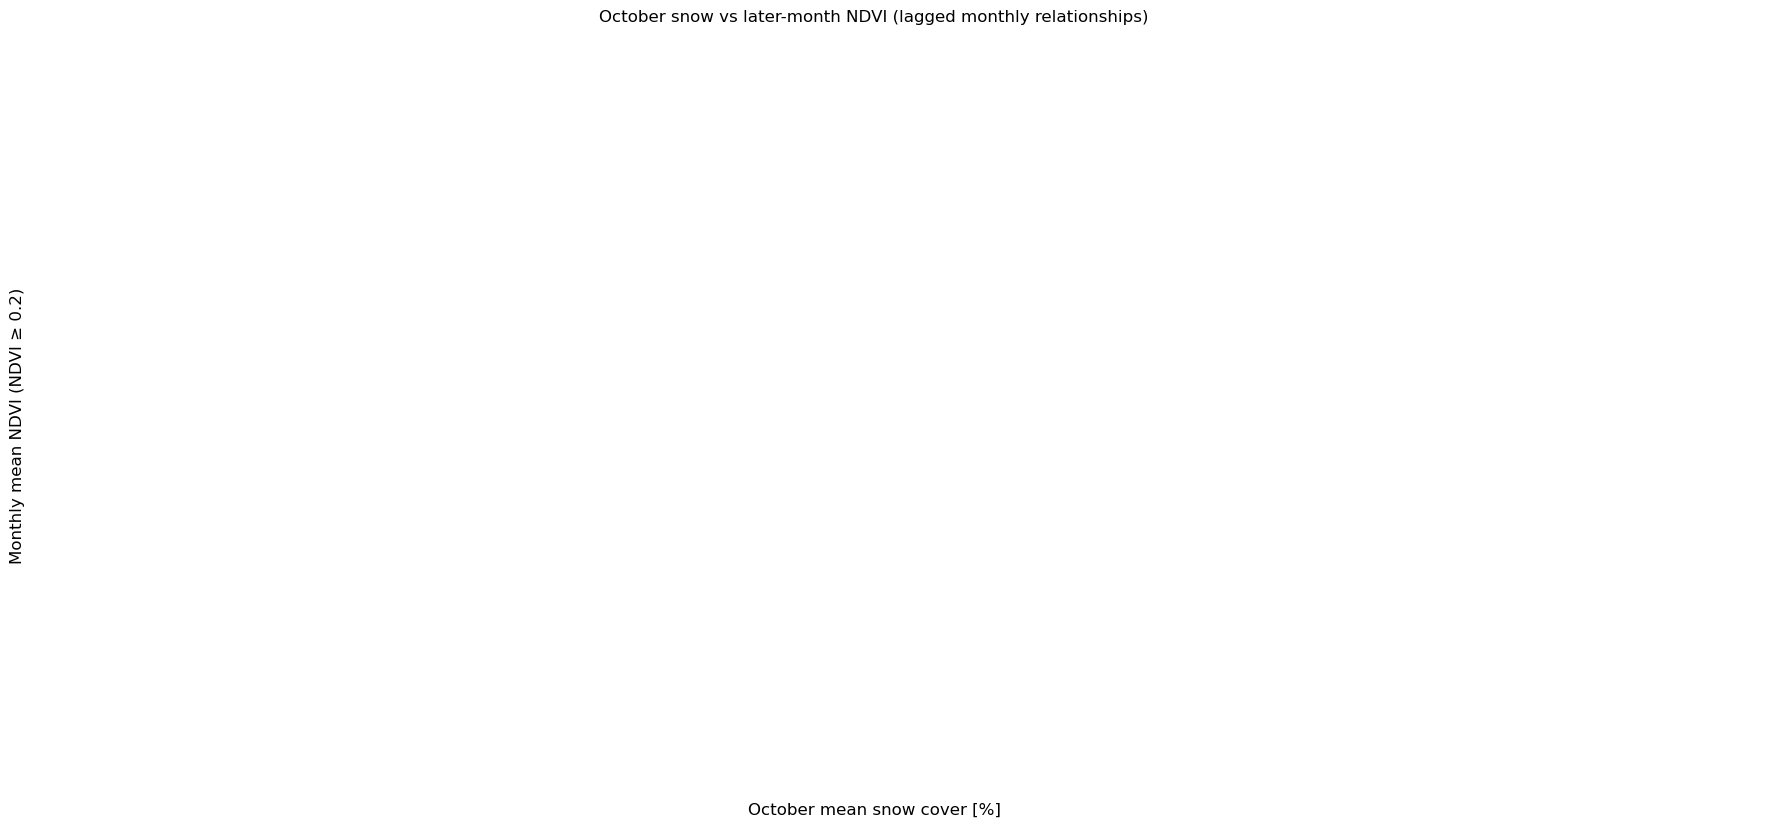

In [203]:
months = [3, 4, 5, 6, 7, 8, 9, 10]
month_names = ['March', 'April', 'May', 'June', 'July', 'August', 'September', 'October']

ndvi_monthly = (
    ndvi_snow.groupby(['Year', 'Month'], as_index=False)
    .agg(NDVI=('NDVI', 'mean'))
)

for i, snow_name in zip(months, month_names):

    # Snow monthly means for the snow month i
    month_snow = (
        ndvi_snow[ndvi_snow['Month'] == i]
        .groupby('Year', as_index=False)['Snow_Percent']
        .mean()
        .rename(columns={'Snow_Percent': f'{snow_name}_Snow'})
    )

    # One figure per snow month: NDVI months laid out consistently across the grid
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, m, ndvi_name in zip(axes, months, month_names):

        if m <= i:
            ax.axis('off')
            continue

        ndvi_m = ndvi_monthly[ndvi_monthly['Month'] == m].copy()
        aligned = month_snow.merge(ndvi_m, on='Year', how='inner')

        x = aligned[f'{snow_name}_Snow']
        y = aligned['NDVI']

        ax.scatter(x, y, alpha=0.6)

        if len(aligned) >= 3:
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = intercept + slope * x_fit

            # Colour by significance
            sig = (p_value <= 0.05)
            line_colour = 'r' if sig else 'grey'
            ax.plot(x_fit, y_fit, linewidth=2, color=line_colour)

            n_obs = len(aligned)
            p_txt = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"

            ax.text(
                0.95, 0.05,
                f'lag = {m - i} mo\n'
                f'n = {n_obs}\n'
                f'r = {r_value:.2f}  ($r^2$ = {r_value**2:.2f})\n'
                f'{p_txt}\n'
                f'NDVI = {slope:.3f} × Snow + {intercept:.3f}',
                transform=ax.transAxes,
                va='bottom', ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )
        else:
            ax.text(
                0.95, 0.05,
                'n < 3',
                transform=ax.transAxes,
                va='bottom', ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )

        ax.set_title(f'{ndvi_name} NDVI')
        ax.grid(True, alpha=0.3)

    # Axis labels / title per figure
    fig.supxlabel(f'{snow_name} mean snow cover [%]')
    fig.supylabel('Monthly mean NDVI (NDVI ≥ 0.2)')
    fig.suptitle(f'{snow_name} snow vs later-month NDVI (lagged monthly relationships)', y=1.02)

    #for ax in axes:
    #     if ax.has_data():
    #         ax.set_xlim(20, 60)
    #         ax.set_ylim(0.2, 0.4)

    plt.tight_layout()
    plt.show()


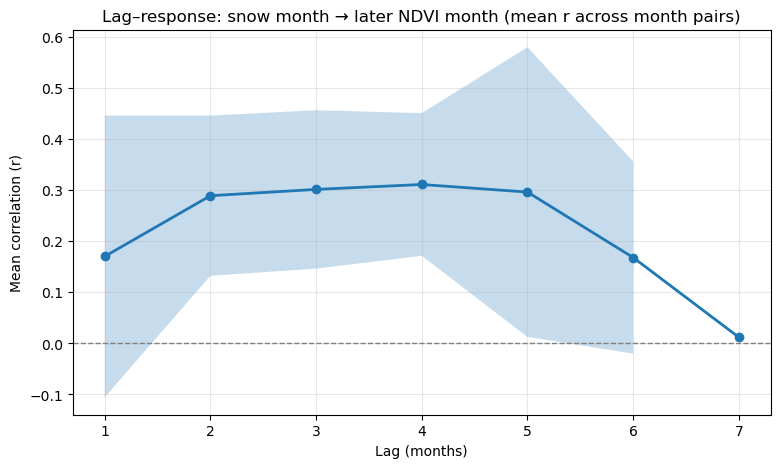

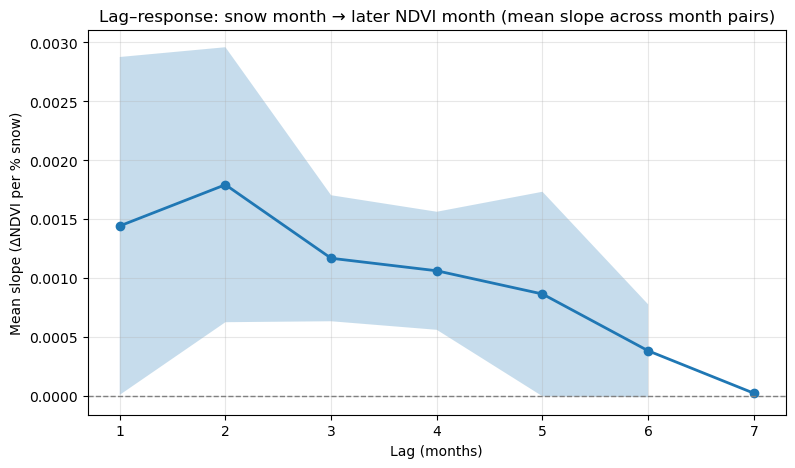

In [204]:

months = [3, 4, 5, 6, 7, 8, 9, 10]
month_names = ['March', 'April', 'May', 'June', 'July', 'August', 'September', 'October']
month_map = dict(zip(months, month_names))

# NDVI monthly means (filter first, then average)
ndvi_monthly = (
    ndvi_snow.loc[ndvi_snow['NDVI'] >= 0.2]
    .groupby(['Year', 'Month'], as_index=False)
    .agg(NDVI=('NDVI', 'mean'))
)

# Collect all month-pair regression results
rows = []

for i in months:
    snow_name = month_map[i]

    month_snow = (
        ndvi_snow[ndvi_snow['Month'] == i]
        .groupby('Year', as_index=False)['Snow_Percent']
        .mean()
        .rename(columns={'Snow_Percent': 'Snow'})
    )

    for m in months:
        if m <= i:
            continue

        ndvi_m = ndvi_monthly[ndvi_monthly['Month'] == m].copy()
        aligned = month_snow.merge(ndvi_m, on='Year', how='inner')

        x = aligned['Snow']
        y = aligned['NDVI']

        valid = x.notna() & y.notna()
        x = x[valid]
        y = y[valid]

        if len(x) < 3:
            continue

        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        rows.append({
            "snow_month": i,
            "ndvi_month": m,
            "lag_months": m - i,
            "n": len(x),
            "slope": slope,
            "intercept": intercept,
            "r": r_value,
            "r2": r_value**2,
            "p": p_value
        })

res = pd.DataFrame(rows)

# Summarise by lag (mean + spread across month-pairs)
lag_summary = (
    res.groupby('lag_months')
       .agg(
           mean_r=('r', 'mean'),
           std_r=('r', 'std'),
           mean_slope=('slope', 'mean'),
           std_slope=('slope', 'std'),
           n_pairs=('r', 'size')
       )
       .reset_index()
)

# --- Plot 1: lag vs mean correlation r (with ±1 std as shading) ---
plt.figure(figsize=(9, 5))
plt.plot(lag_summary['lag_months'], lag_summary['mean_r'], marker='o', linewidth=2)
plt.fill_between(
    lag_summary['lag_months'],
    lag_summary['mean_r'] - lag_summary['std_r'],
    lag_summary['mean_r'] + lag_summary['std_r'],
    alpha=0.25
)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.xlabel('Lag (months)')
plt.ylabel('Mean correlation (r)')
plt.title('Lag–response: snow month → later NDVI month (mean r across month pairs)')
plt.grid(alpha=0.3)
plt.show()

# --- Plot 2 (optional): lag vs mean slope (with ±1 std as shading) ---
plt.figure(figsize=(9, 5))
plt.plot(lag_summary['lag_months'], lag_summary['mean_slope'], marker='o', linewidth=2)
plt.fill_between(
    lag_summary['lag_months'],
    lag_summary['mean_slope'] - lag_summary['std_slope'],
    lag_summary['mean_slope'] + lag_summary['std_slope'],
    alpha=0.25
)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.xlabel('Lag (months)')
plt.ylabel('Mean slope (ΔNDVI per % snow)')
plt.title('Lag–response: snow month → later NDVI month (mean slope across month pairs)')
plt.grid(alpha=0.3)
plt.show()

# If you want to inspect the raw month-pair table:
# display(res.sort_values(['lag_months', 'snow_month', 'ndvi_month']))


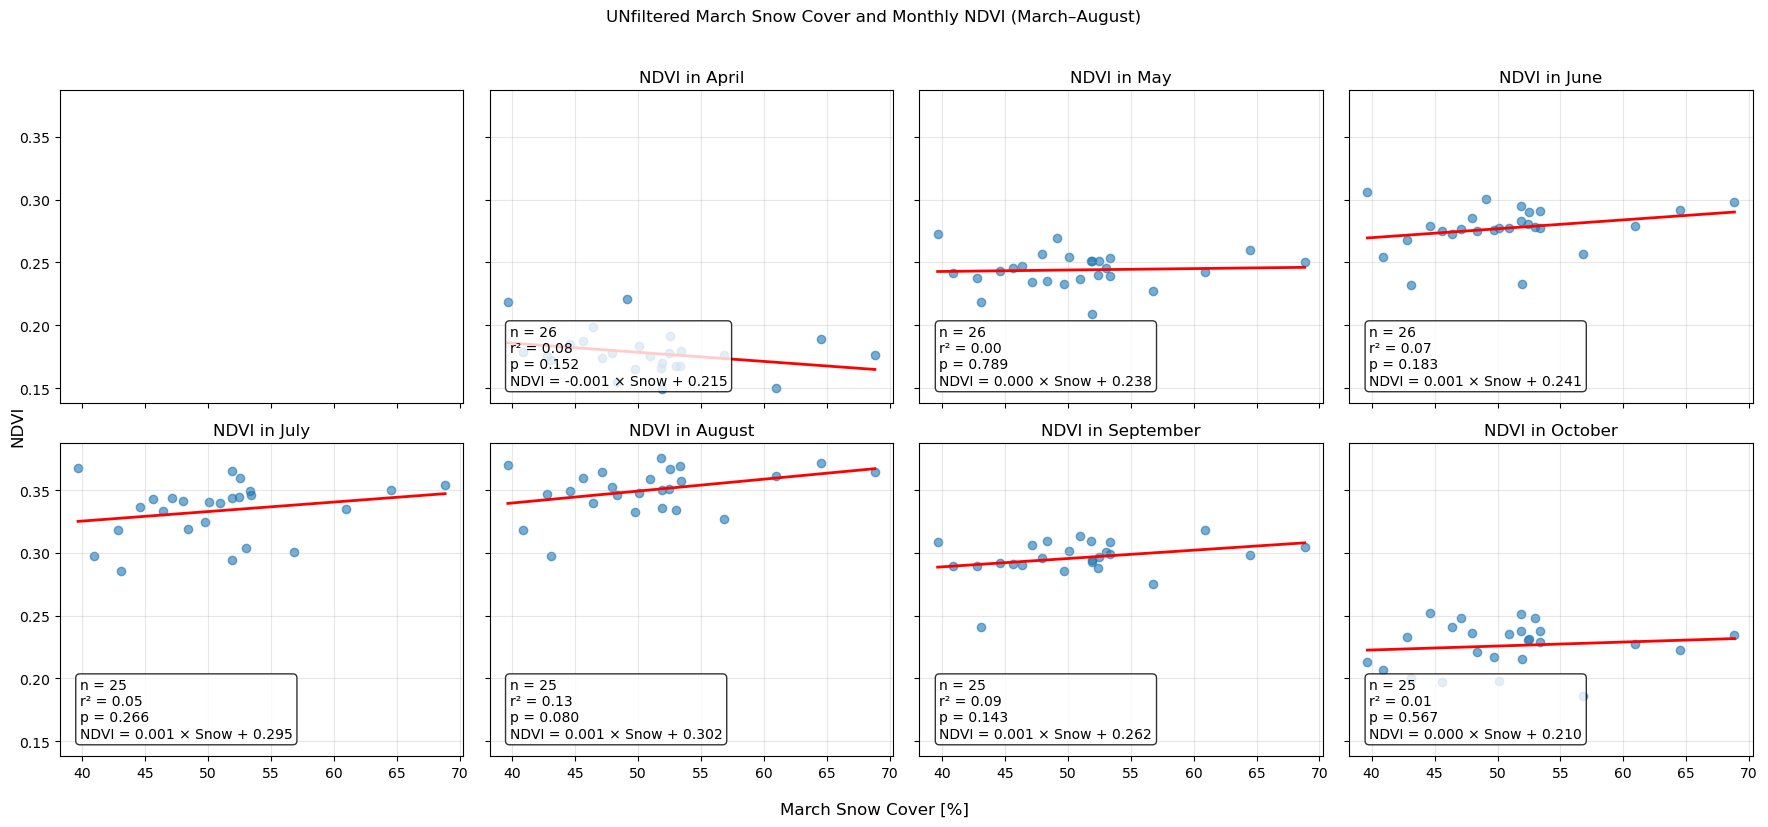

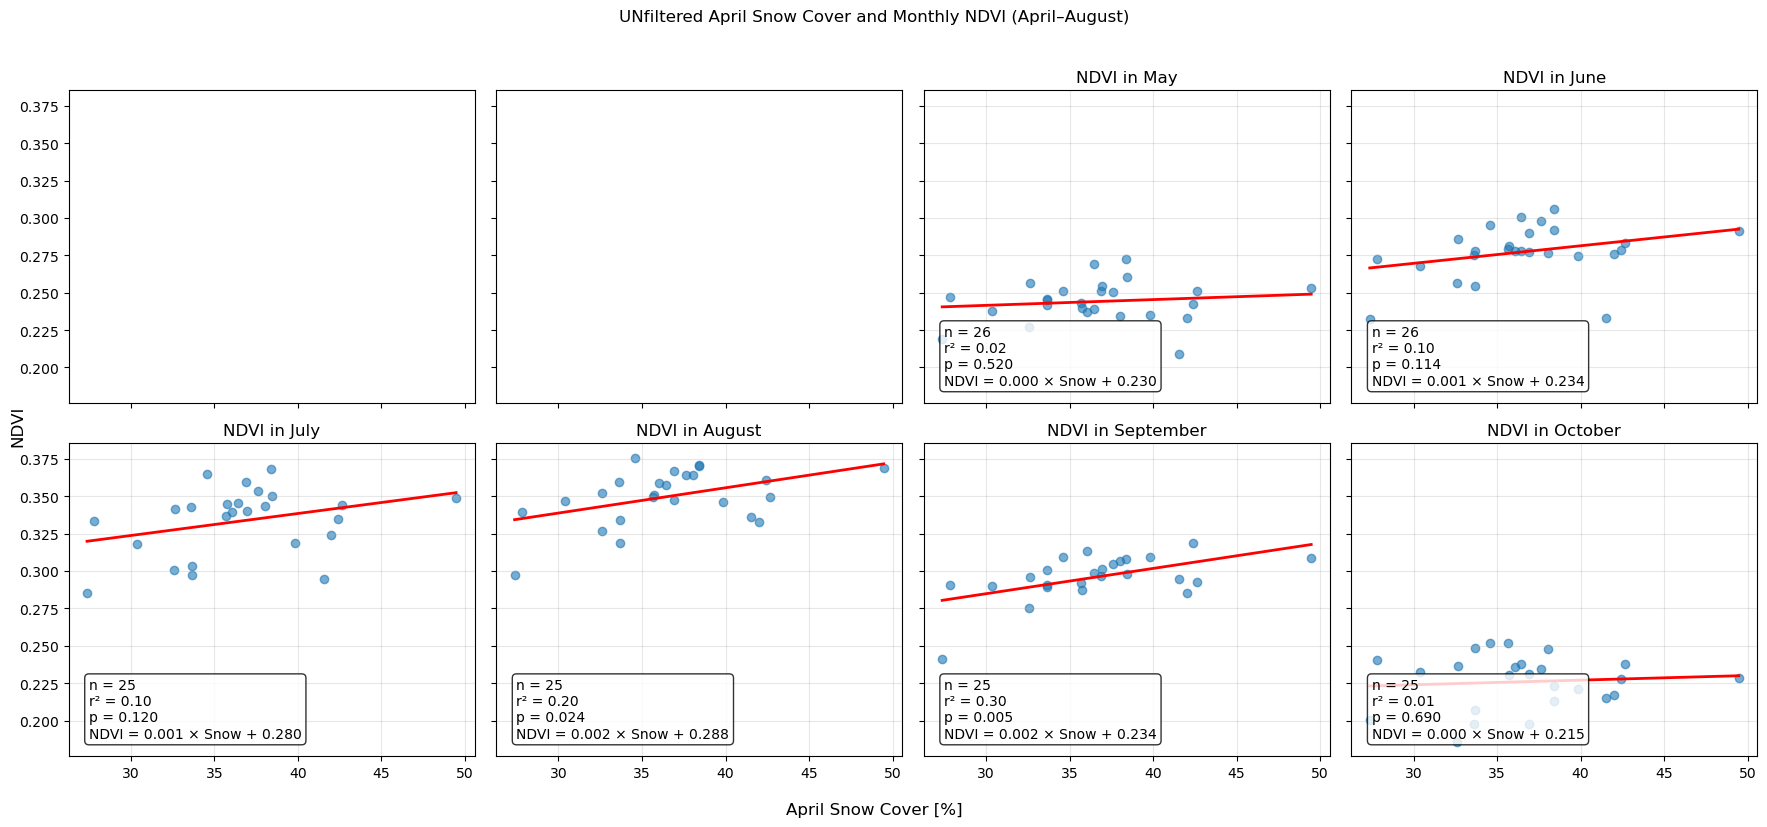

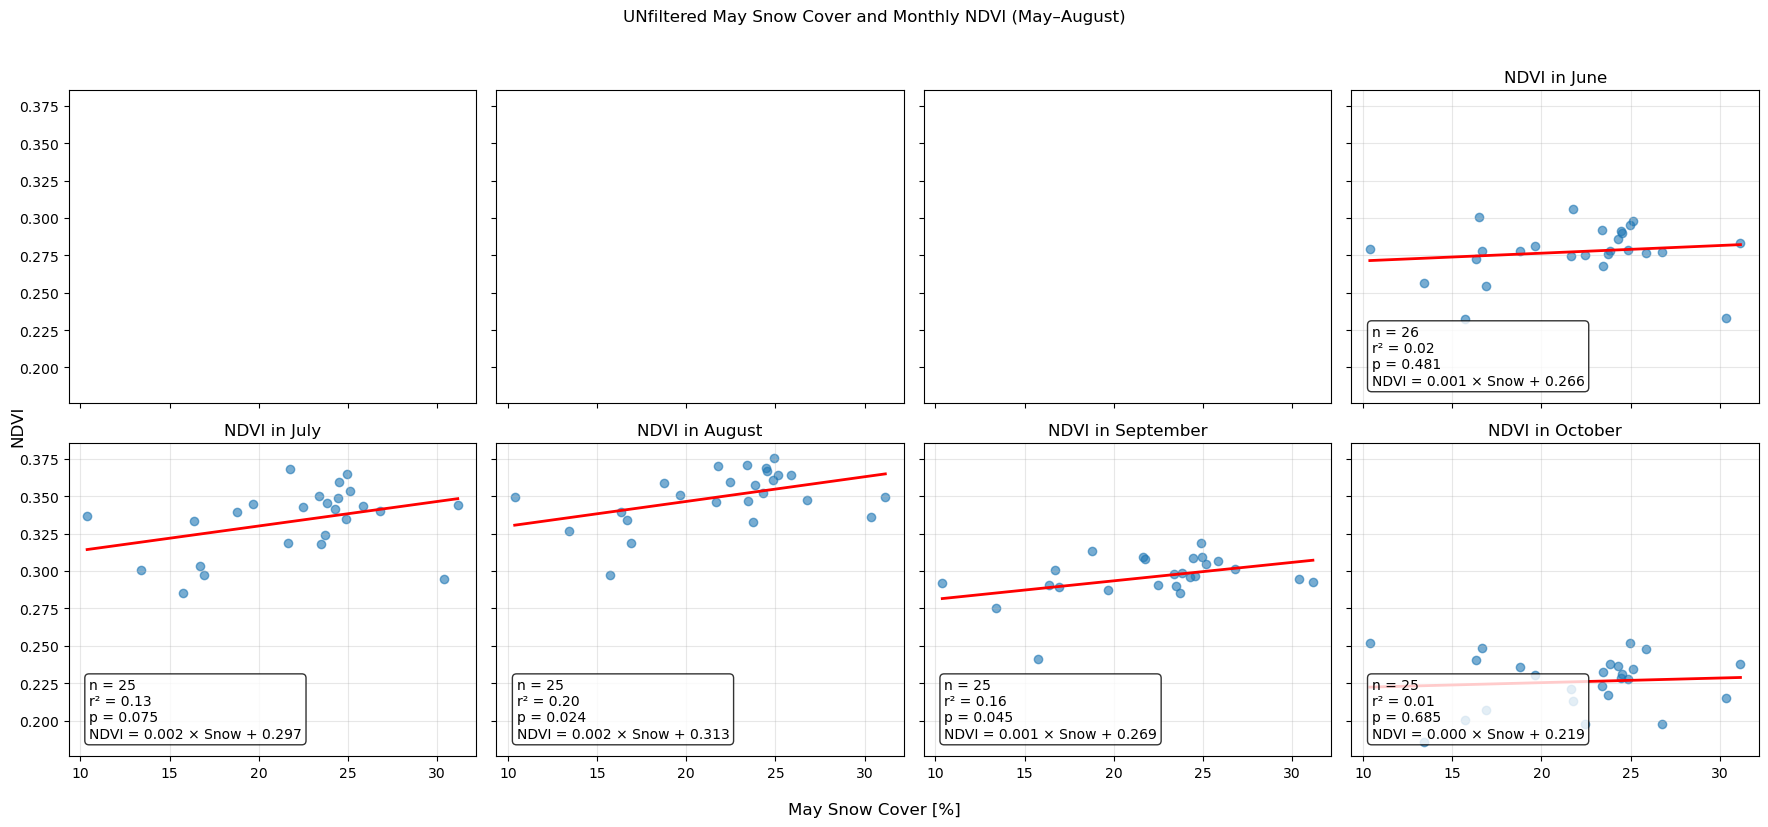

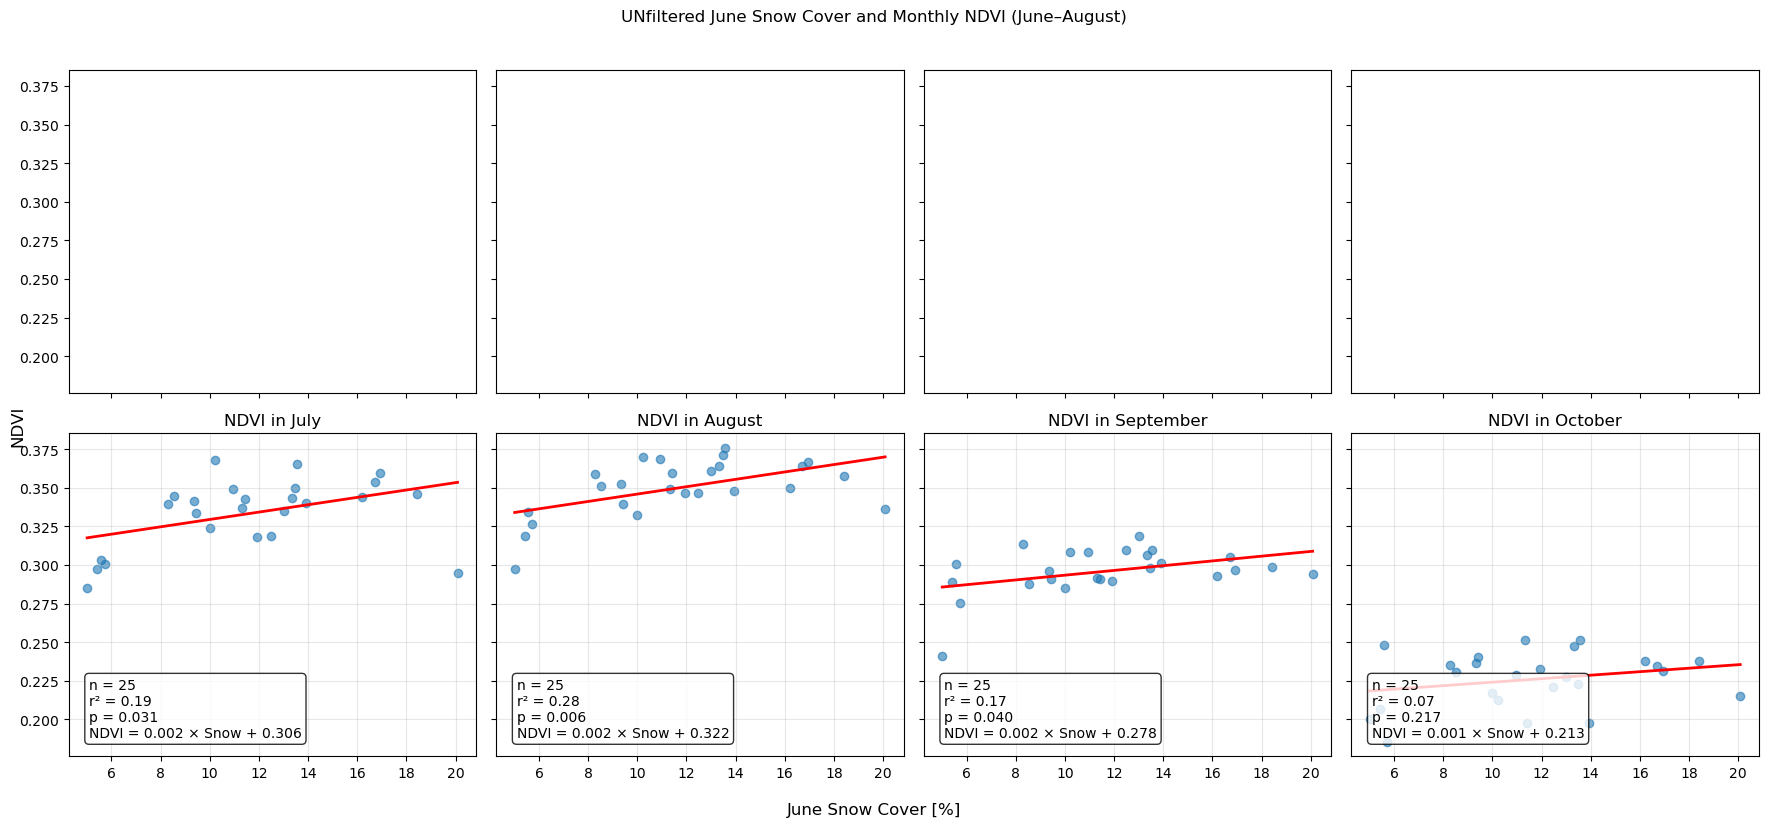

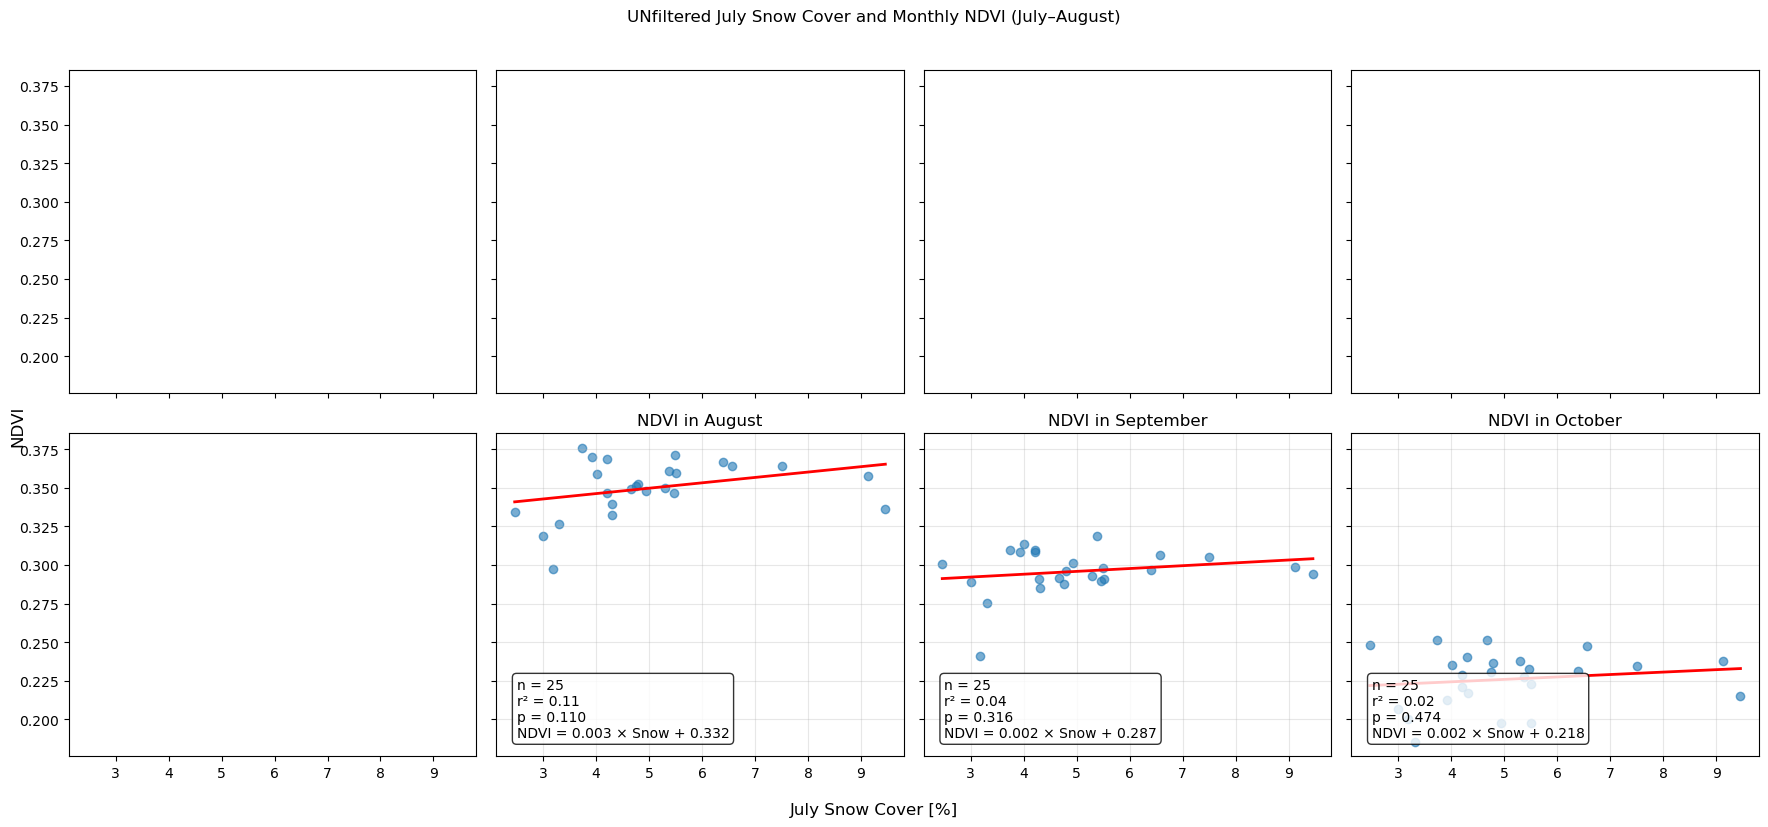

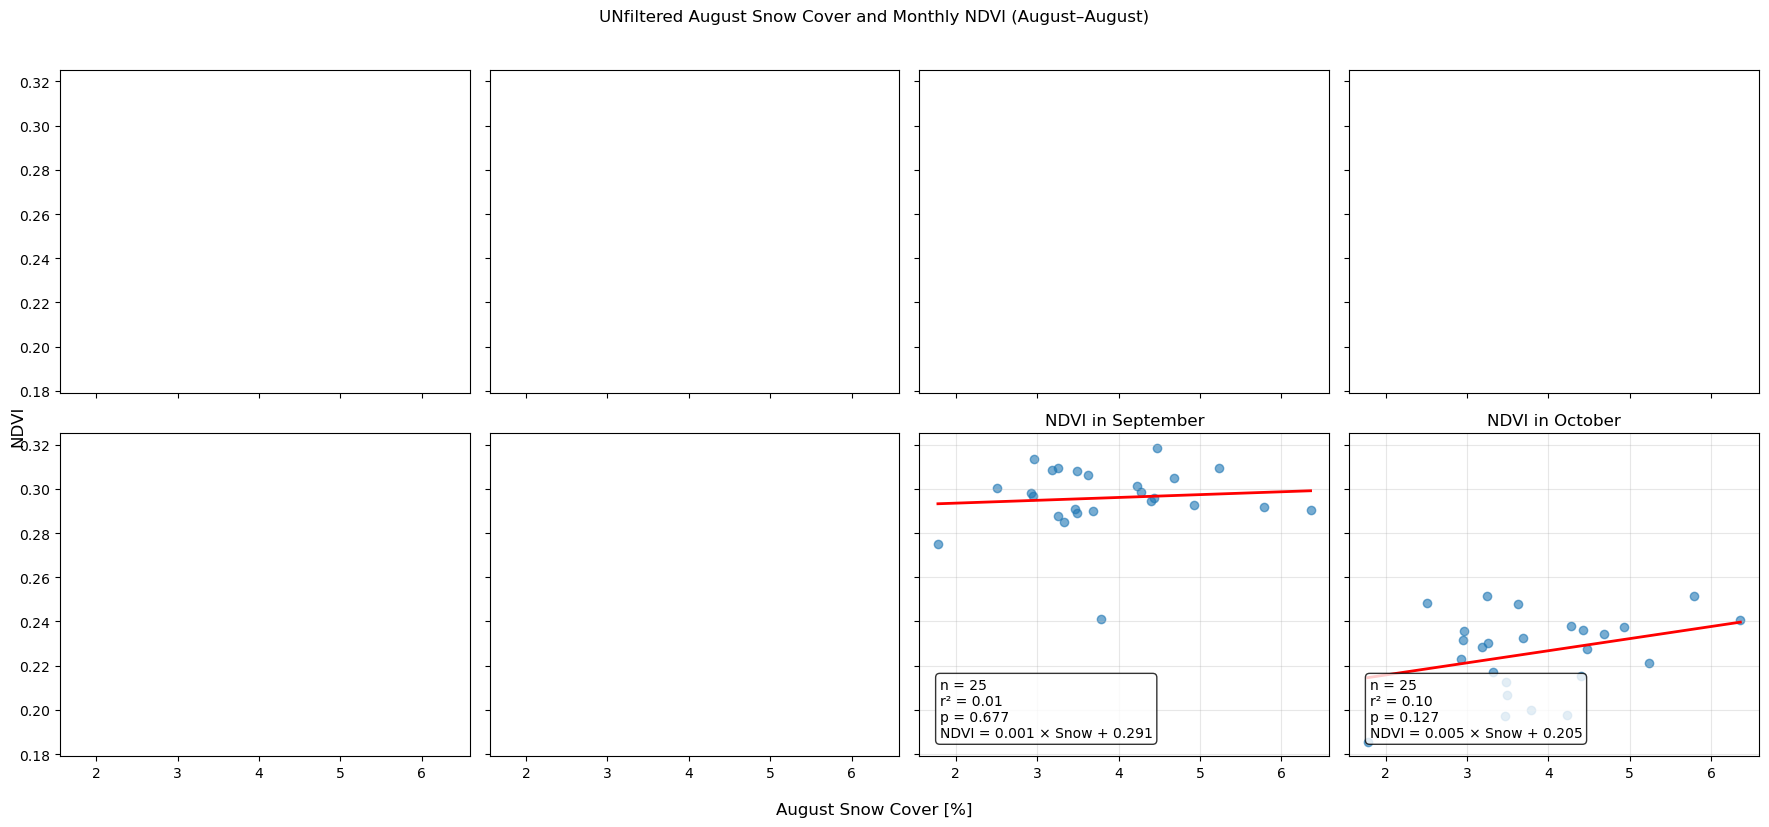

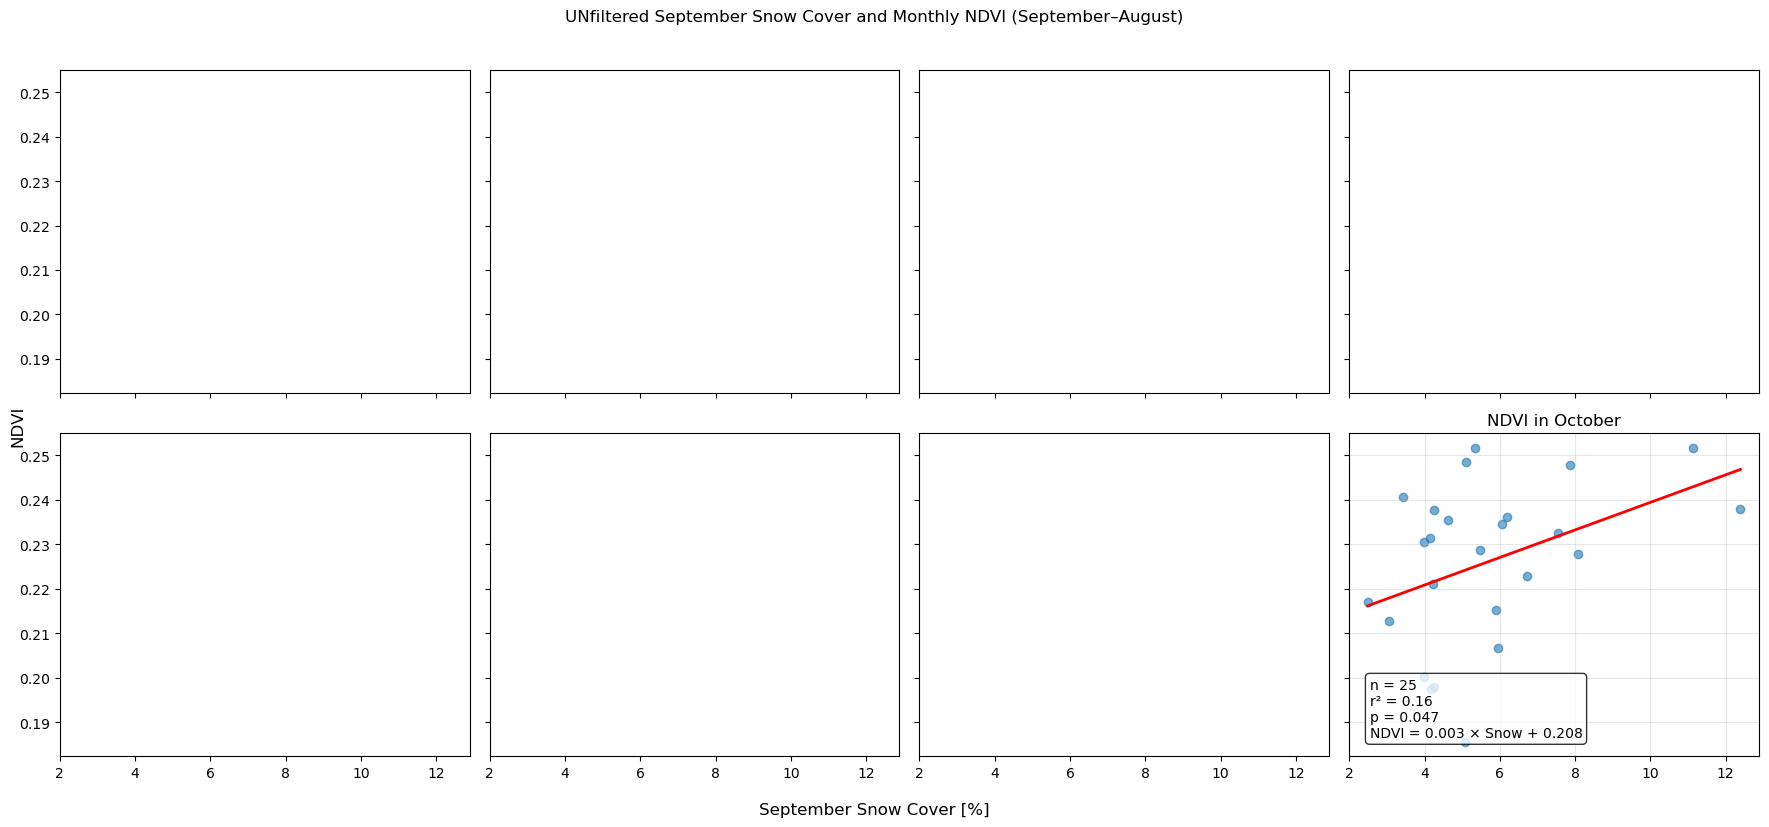

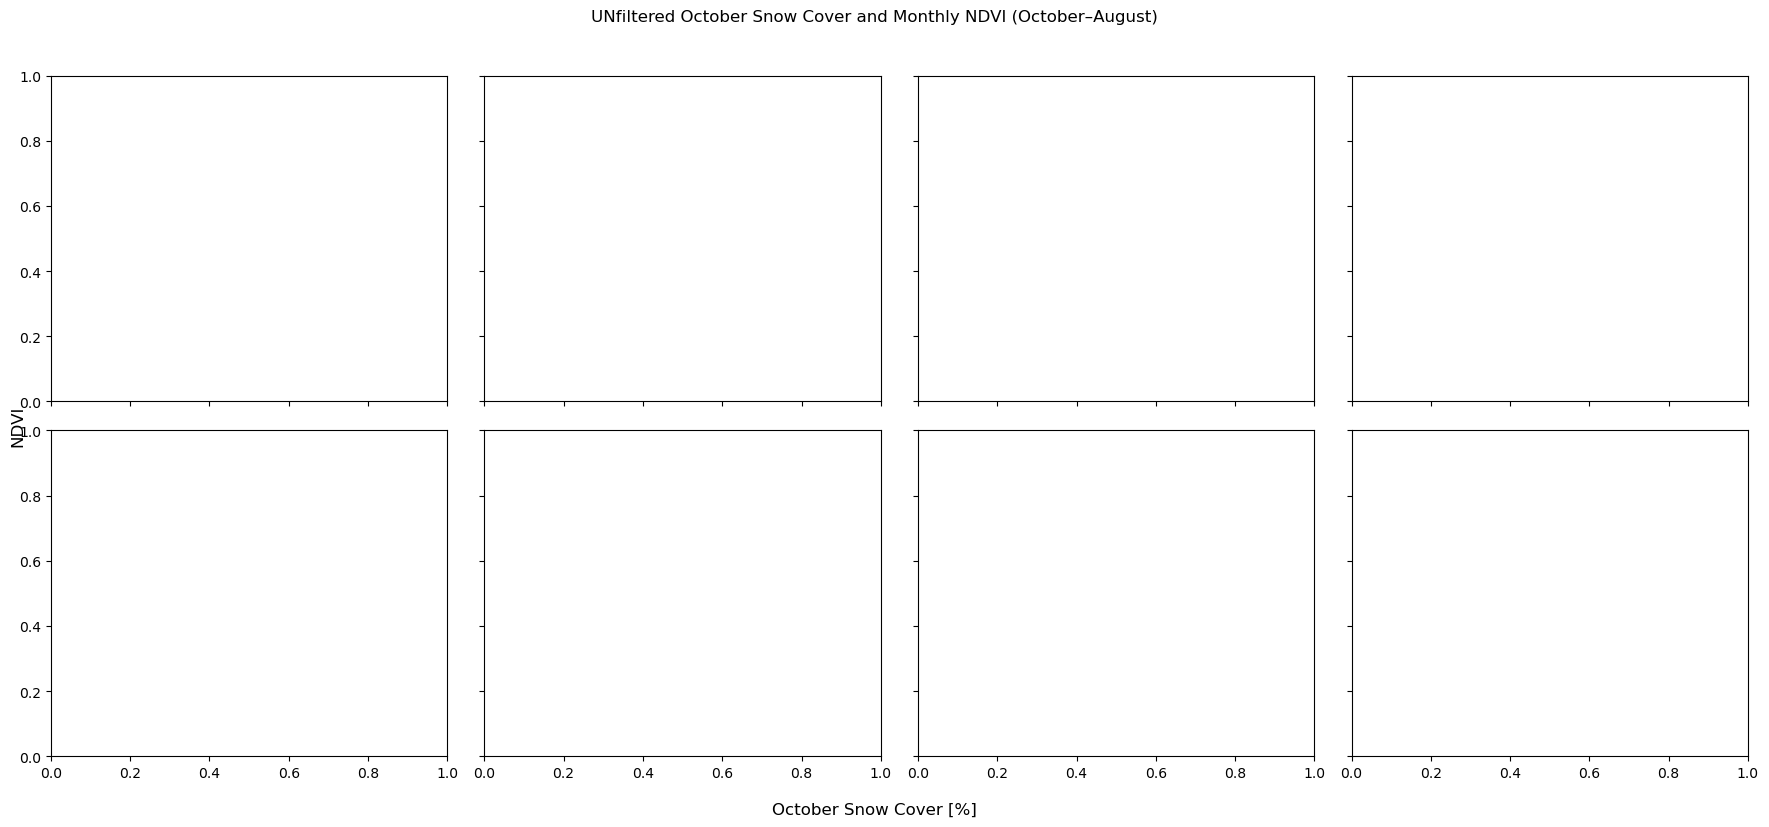

In [165]:
months = [3, 4, 5, 6, 7, 8, 9, 10]
month_names = ['March', 'April', 'May', 'June', 'July', 'August', 'September', 'October']

ndvi_monthly = (
    ndvi_snow
    .groupby(['Year', 'Month'], as_index=False)
    .agg(NDVI=('NDVI', 'mean'))  
)

for i, n in zip(months, month_names):

    month_snow = (
    ndvi_snow[ndvi_snow['Month'] == i]
    .groupby(['Year', 'Month'])['Snow_Percent']
    .mean()
    .reset_index()
    .rename(columns={'Snow_Percent': f'{n}_Snow'})
    .drop(columns='Month')
    )

    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, m, name in zip(axes, months, month_names):

        if m <= i:
            continue

        ndvi_m = ndvi_monthly[ndvi_monthly['Month'] == m].copy()

        aligned = month_snow.merge(ndvi_m, on='Year', how='inner')

        x = aligned[f'{n}_Snow']
        y = aligned['NDVI']

        ax.scatter(x, y, alpha=0.6)

        if len(aligned) >= 3:
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = intercept + slope * x_fit

            ax.plot(x_fit, y_fit, linewidth=2, color='r')

            n_obs = len(aligned)
            p_txt = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"

            ax.text(
                0.05, 0.05,
                f'n = {n_obs}\n'
                f'r² = {r_value**2:.2f}\n'
                f'{p_txt}\n'
                f'NDVI = {slope:.3f} × Snow + {intercept:.3f}',
                transform=ax.transAxes,
                va='bottom', ha='left',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )
            
        else:
            ax.text(
                0.05, 0.95,
                'n < 3',
                transform=ax.transAxes,
                va='top', ha='left'
            )

        ax.set_title(f'NDVI in {name}')
        ax.grid(True, alpha=0.3)

    fig.supxlabel(f'{n} Snow Cover [%]')
    fig.supylabel('NDVI')
    fig.suptitle(f'UNfiltered {n} Snow Cover and Monthly NDVI ({n}–August)', y=1.02)

    plt.tight_layout()
    plt.show()

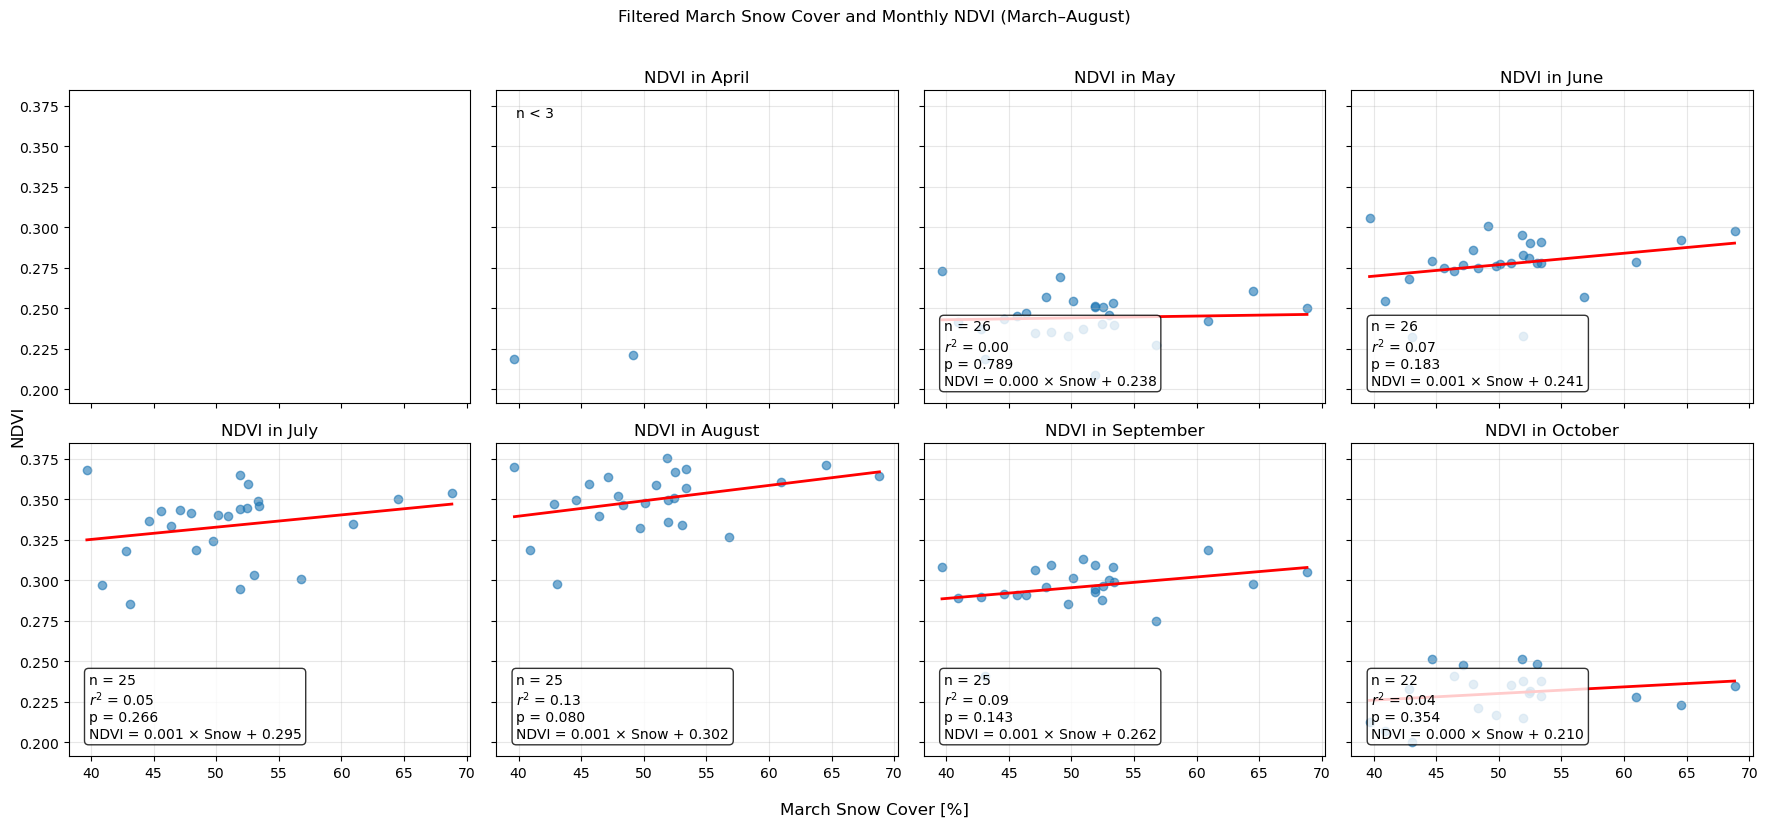

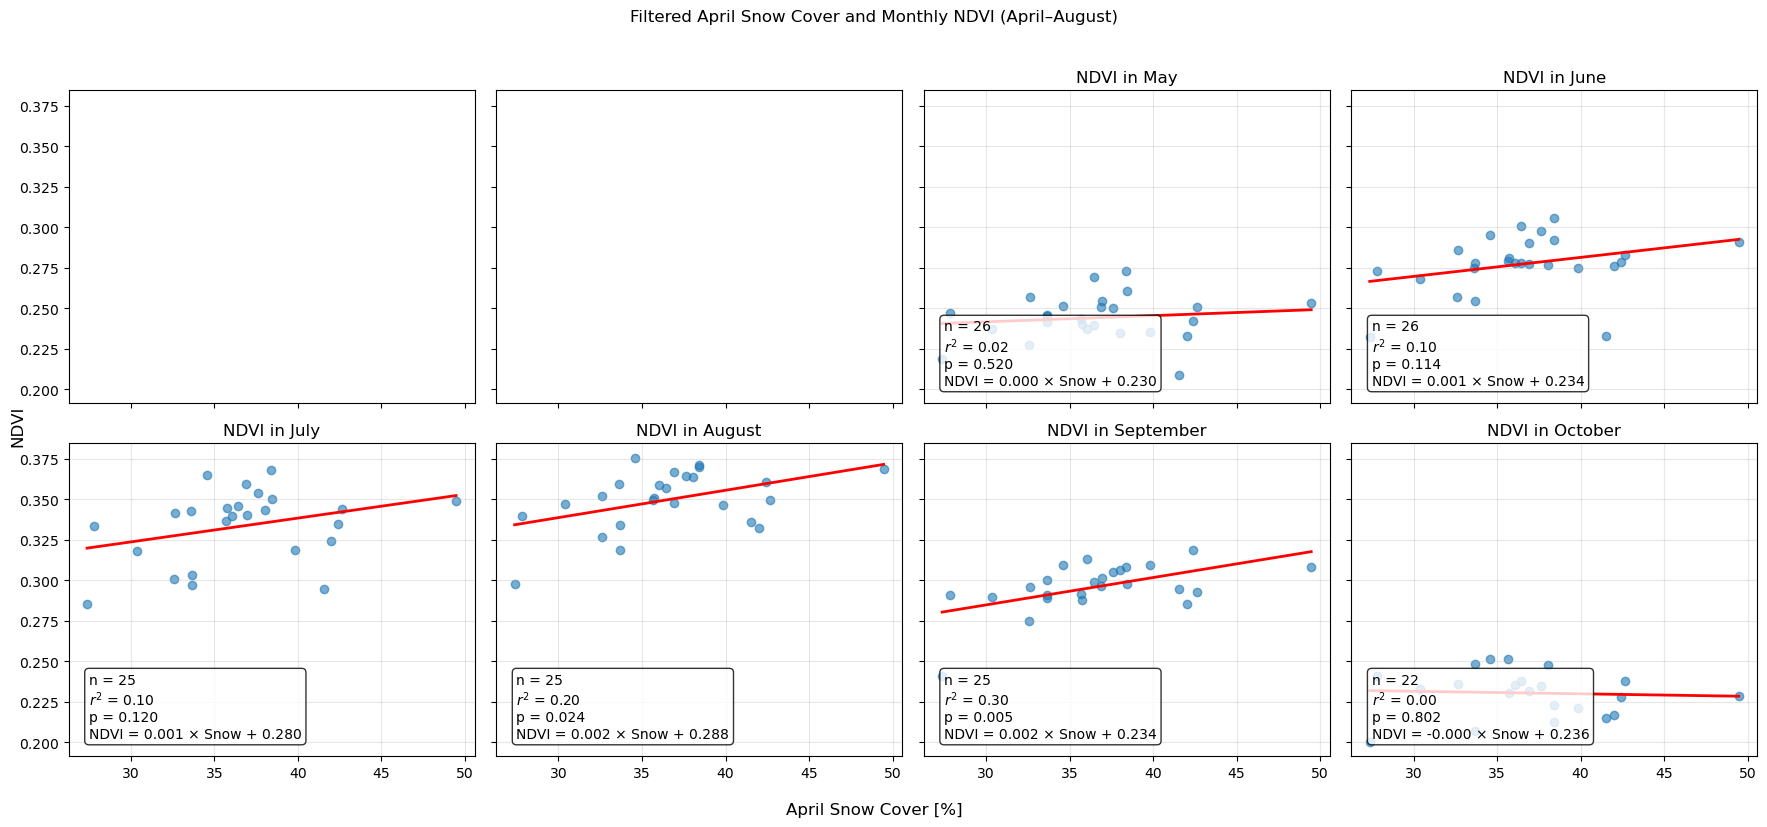

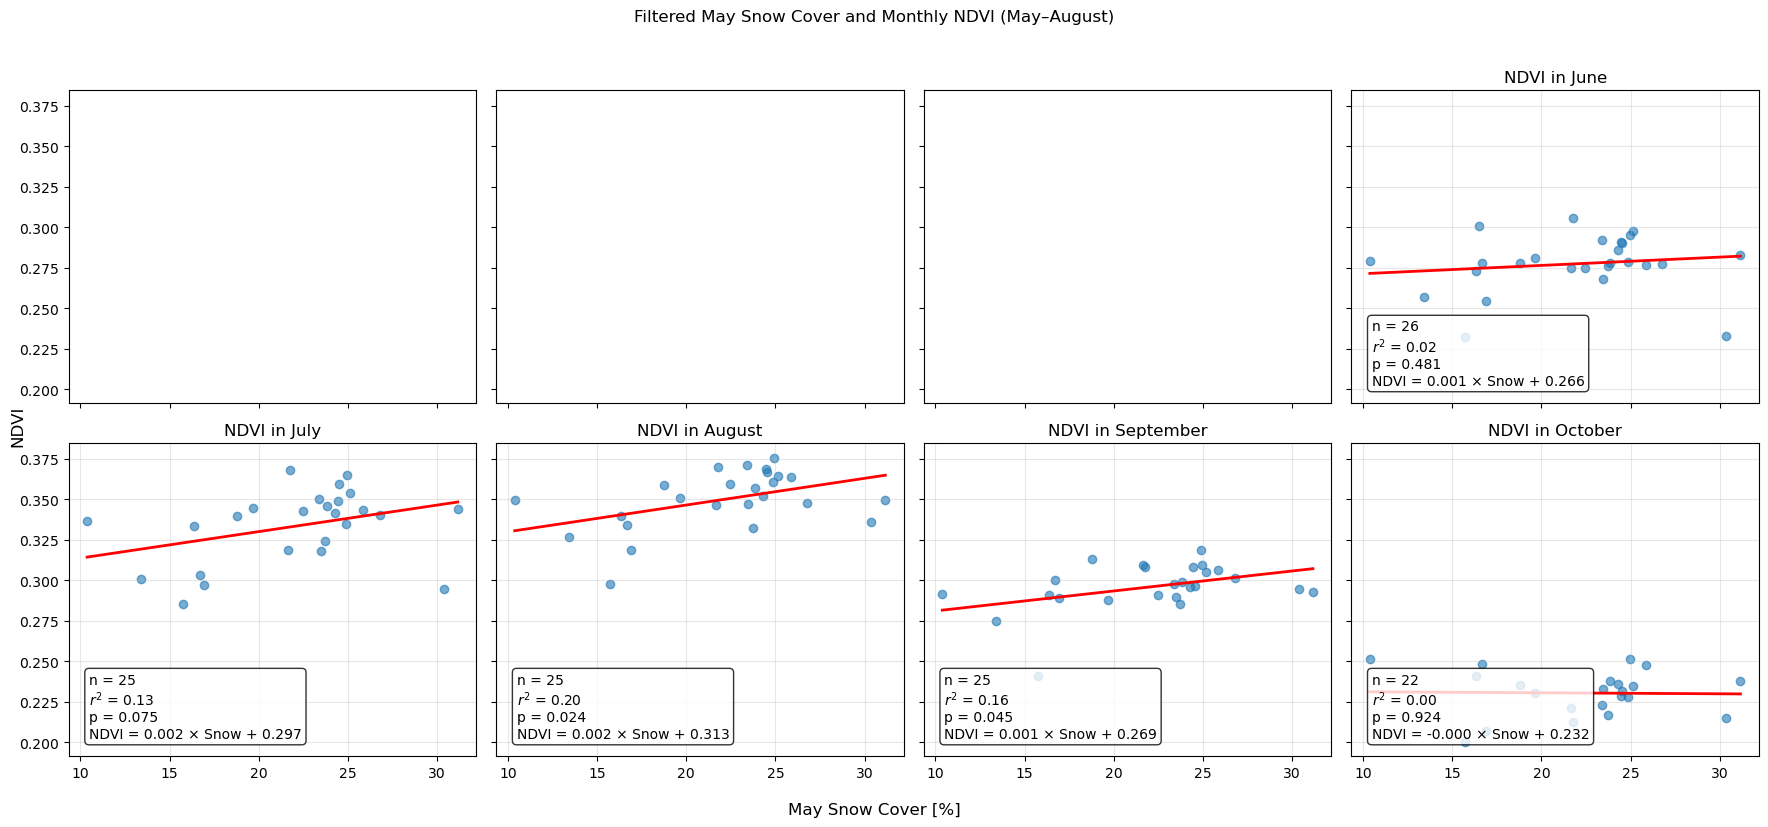

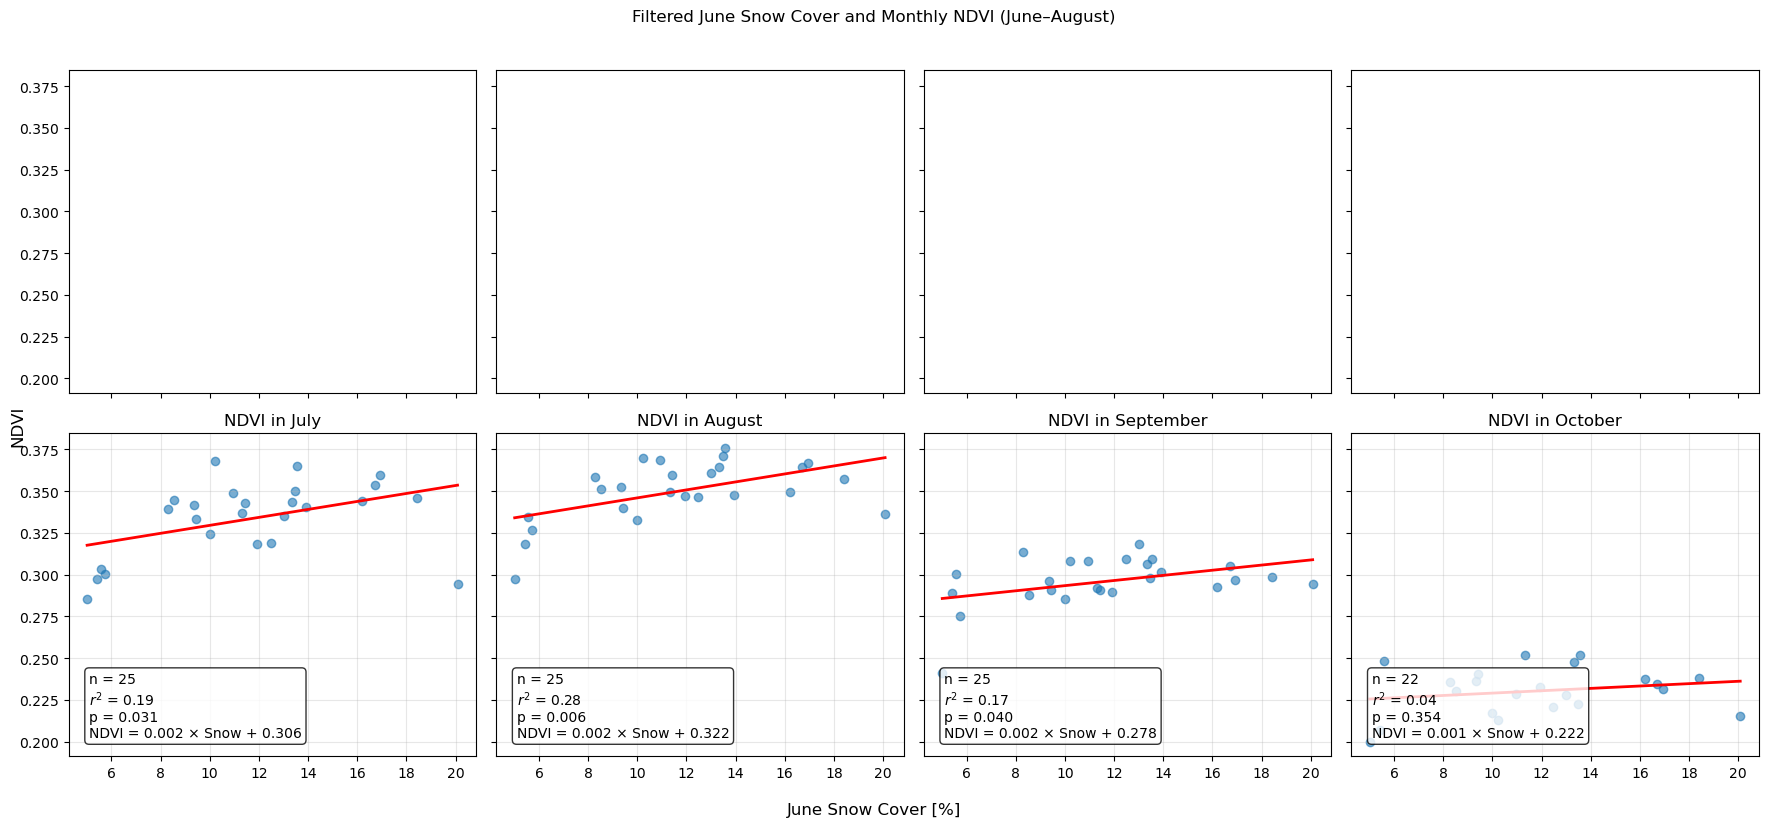

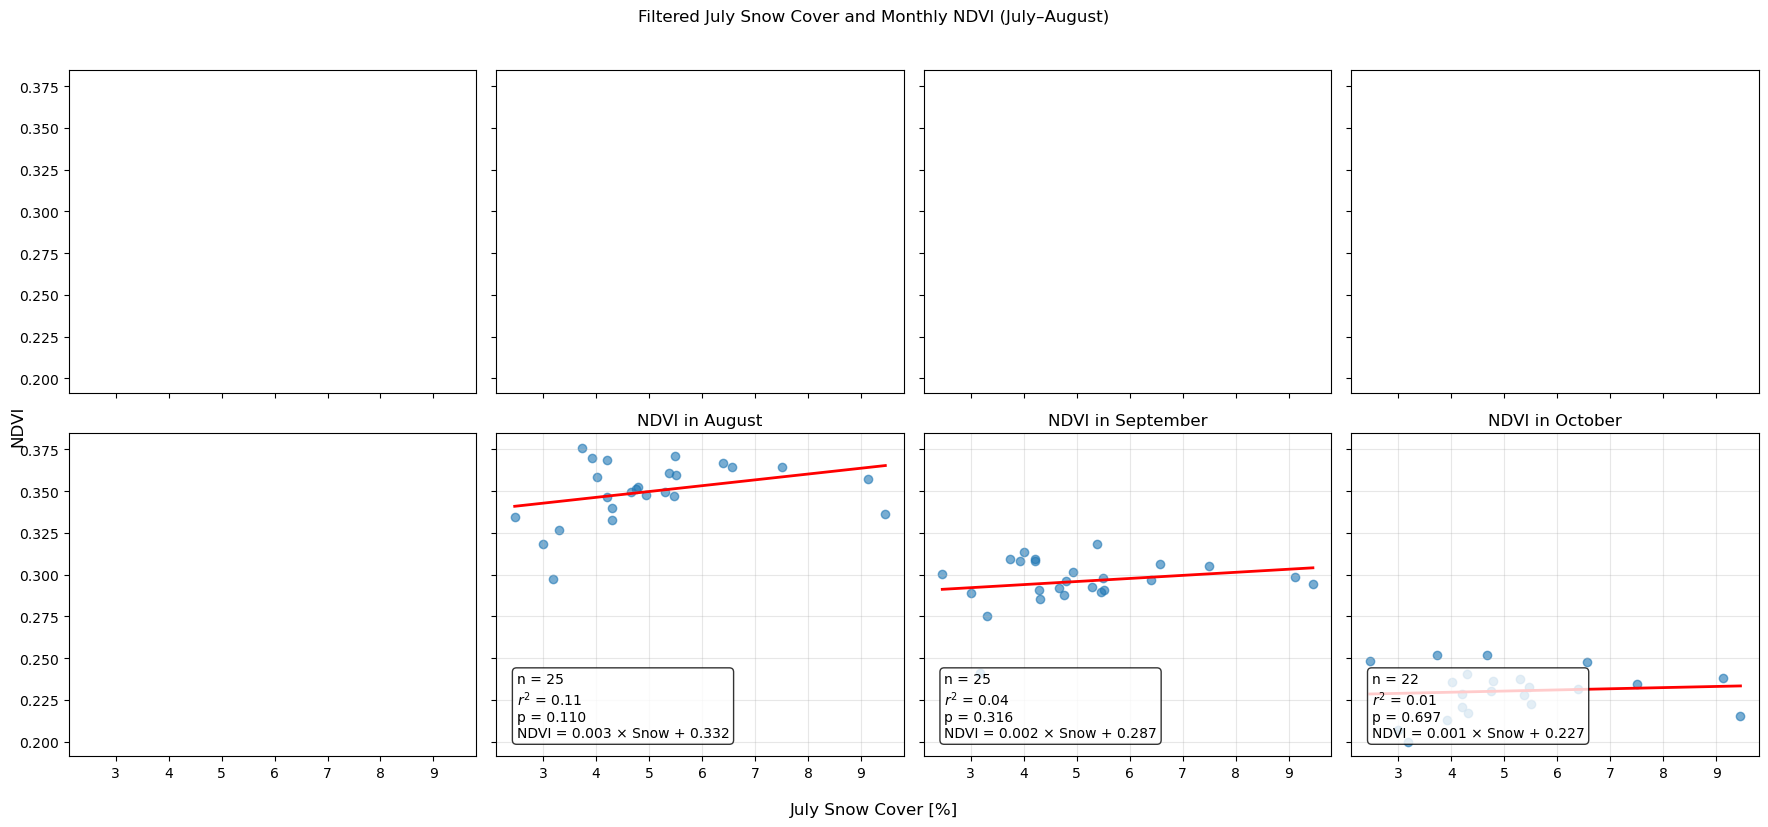

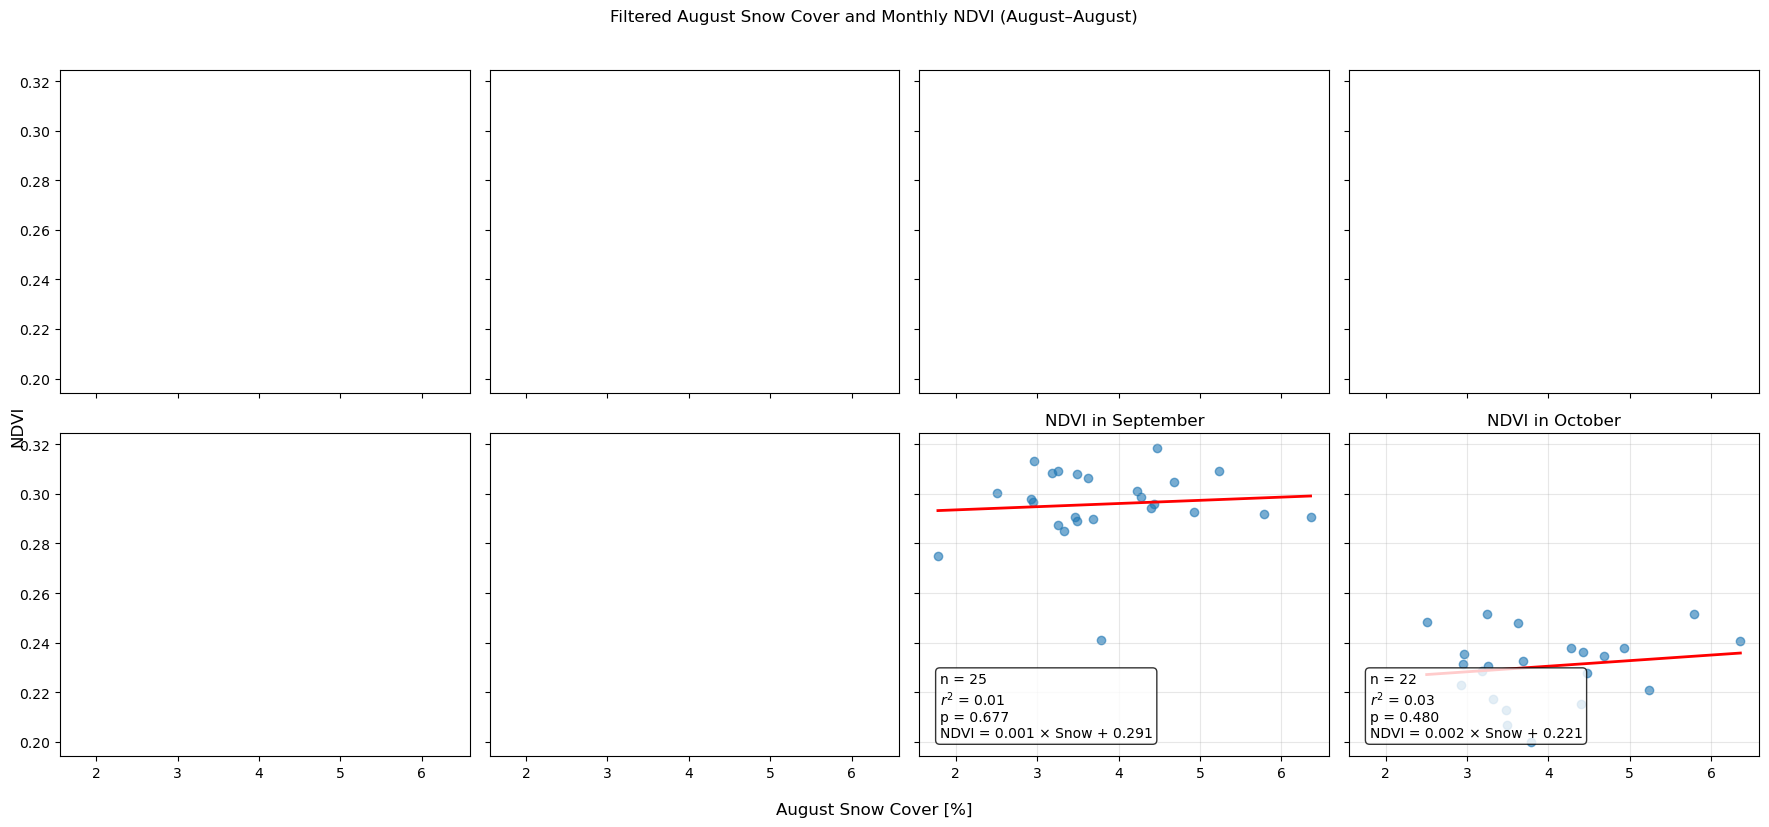

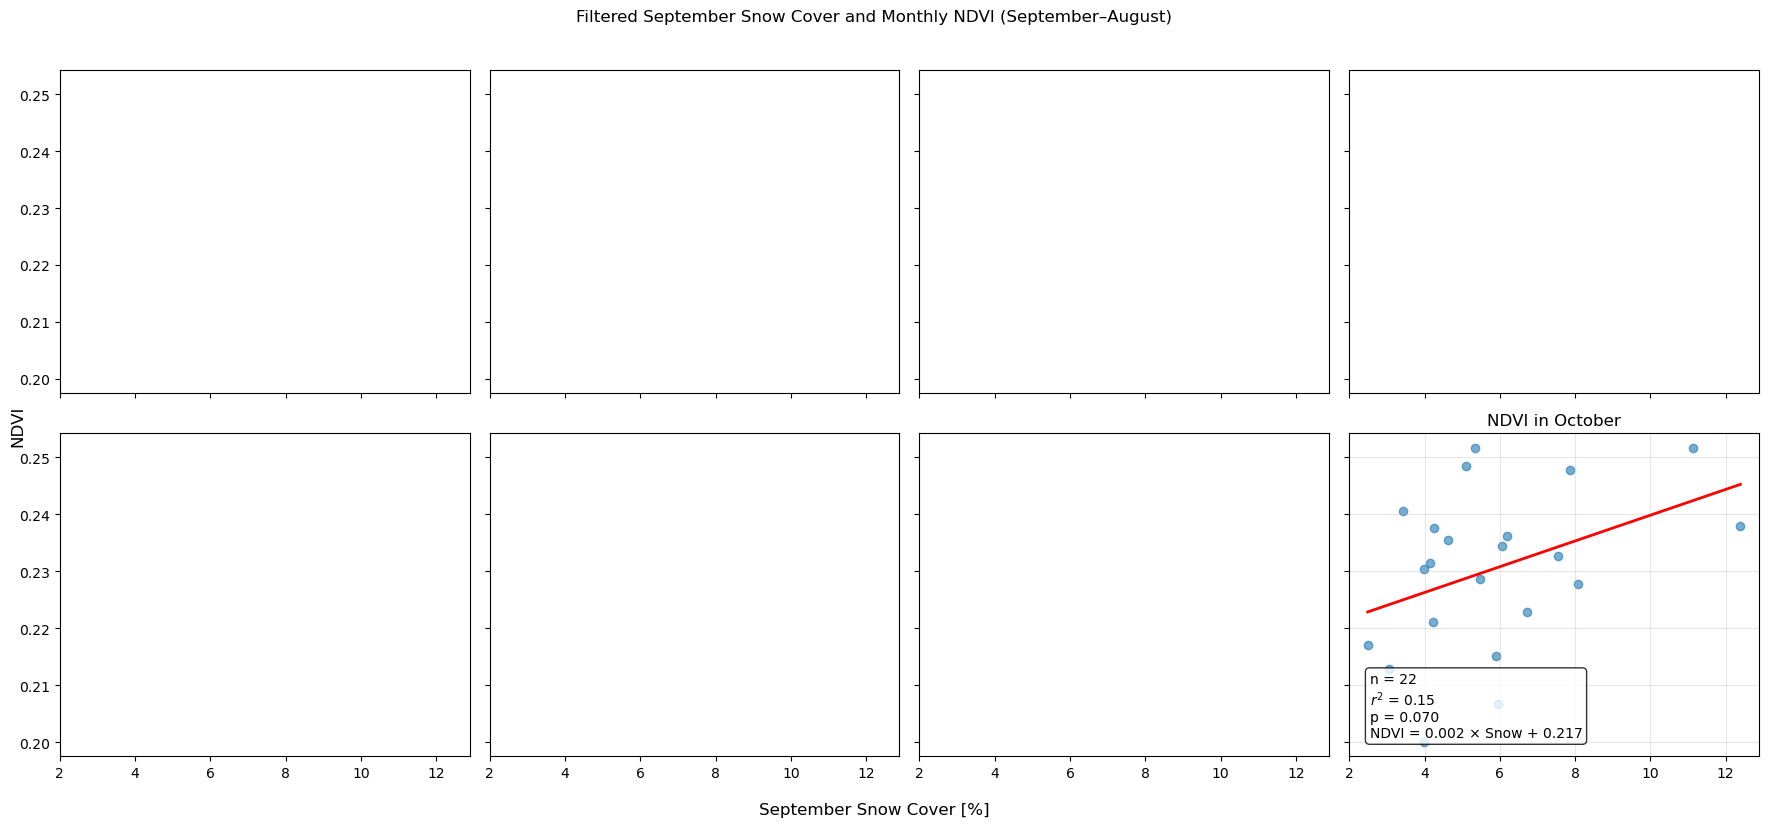

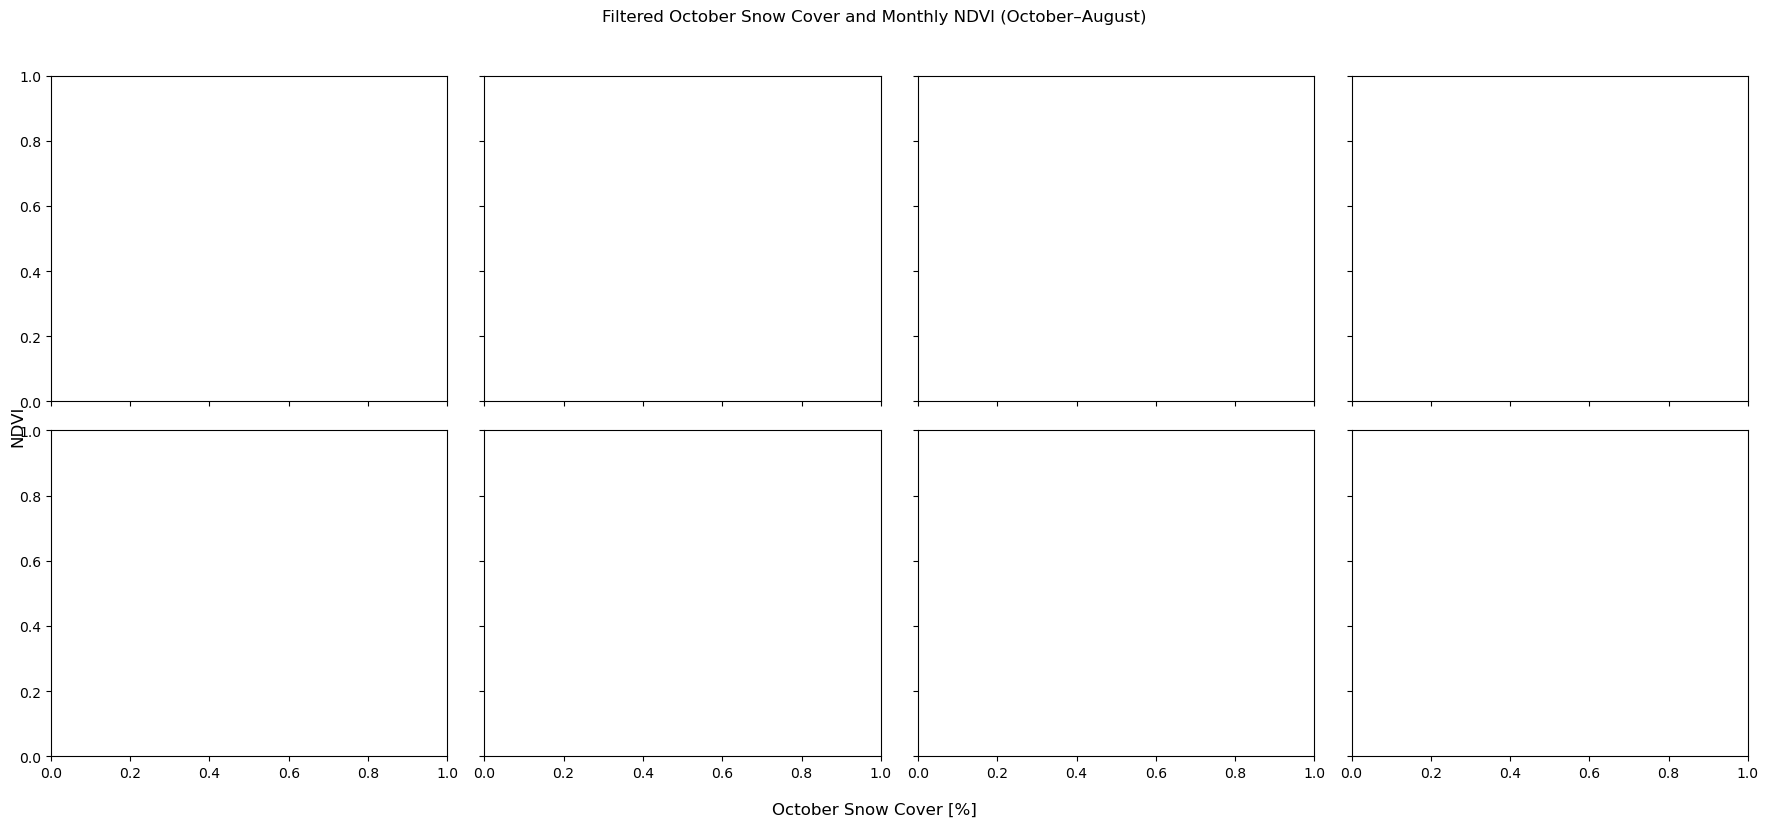

In [168]:
months = [3, 4, 5, 6, 7, 8, 9, 10]
month_names = ['March', 'April', 'May', 'June', 'July', 'August', 'September', 'October']

ndvi_monthly = (
    ndvi_snow
    .groupby(['Year', 'Month'], as_index=False)
    .agg(NDVI=('NDVI', 'mean'))  
)

for i, n in zip(months, month_names):

    month_snow = (
    ndvi_snow[ndvi_snow['Month'] == i]
    .groupby(['Year', 'Month'])['Snow_Percent']
    .mean()
    .reset_index()
    .rename(columns={'Snow_Percent': f'{n}_Snow'})
    .drop(columns='Month')
    )

    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, m, name in zip(axes, months, month_names):

        if m <= i:
            continue

        ndvi_m = ndvi_monthly[ndvi_monthly['Month'] == m].copy()
        ndvi_m = ndvi_m[ndvi_m['NDVI'] >= 0.2]

        aligned = month_snow.merge(ndvi_m, on='Year', how='inner')

        x = aligned[f'{n}_Snow']
        y = aligned['NDVI']

        ax.scatter(x, y, alpha=0.6)

        if len(aligned) >= 3:
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = intercept + slope * x_fit

            ax.plot(x_fit, y_fit, linewidth=2, color='r')

            n_obs = len(aligned)
            p_txt = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"

            ax.text(
                0.05, 0.05,
                f'n = {n_obs}\n'
                f'$r^2$ = {r_value**2:.2f}\n'
                f'{p_txt}\n'
                f'NDVI = {slope:.3f} × Snow + {intercept:.3f}',
                transform=ax.transAxes,
                va='bottom', ha='left',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )
            
        else:
            ax.text(
                0.05, 0.95,
                'n < 3',
                transform=ax.transAxes,
                va='top', ha='left'
            )

        ax.set_title(f'NDVI in {name}')
        ax.grid(True, alpha=0.3)

    fig.supxlabel(f'{n} Snow Cover [%]')
    fig.supylabel('NDVI')
    fig.suptitle(f'Filtered {n} Snow Cover and Monthly NDVI ({n}–August)', y=1.02)

    plt.tight_layout()
    plt.show()